# Project Capstone: Corporate Contract Review & Compliance Audit Agent System

**An end-to-end, production-grade multi-agent AI system that autonomously reviews vendor contracts for policy violations, scores overall contract risk, rewrites and verifies non-compliant clauses through confidence-gated retry loops, tracks execution cost, and produces a structured audit report.**

---

## System Architecture Overview — 7-Agent Pipeline with Retry Loops

```
ContractParserAgent        (Agent 1 — LLM-powered clause splitting)
        ↓
PolicyRetrievalAgent  ←→  ChromaDB        (Agent 2 — retrieval + severity ranking)
        ↓
ComplianceJudgeAgent  ←→  Groq LLM        (Agent 3 — Compliant / Non-Compliant verdicts)
        ↓  ⟲ low confidence → re-judge (Agent 6 triggers Agent 3 again)
RiskScoringAgent                          (Agent 4 — 0-100 contract Risk Score)
        ↓
ContractRewriterAgent ←→  Groq LLM        (Agent 5 — compliance-ready rewritten contract)
        ↓
ReviewerAgent         ←→  Groq LLM        (Agent 7 — verifies every rewrite)
        ↓  ⟲ failed review → re-rewrite (Agent 6 triggers Agent 5 again)
OrchestratorAgent → Final Report          (Agent 6 — drives all agents, assembles output)
```

```
┌─────────────────────────────────────────────────────────────────────┐
│                CONTRACT AUDIT MULTI-AGENT SYSTEM                    │
│                                                                     │
│  ┌──────────────┐    ┌──────────────────┐    ┌──────────────────┐  │
│  │  Simulated   │    │  ChromaDB Vector │    │   Groq LLM API   │  │
│  │  AWS S3      │───▶│  Knowledge Base  │───▶│  (llama3-70b)    │  │
│  │  Ingestion   │    │  (Policy Rules)  │    │  Judge + Rewriter│  │
│  └──────────────┘    └──────────────────┘    │  + Reviewer      │  │
│         │                    │                └──────────────────┘  │
│         ▼                    ▼                        │             │
│  ┌──────────────────────────────────────────────────────────────┐  │
│  │   OrchestratorAgent — confidence-gated retry control flow    │  │
│  │   low confidence → re-judge │ failed review → re-rewrite     │  │
│  └──────────────────────────────────────────────────────────────┘  │
│         │                                                           │
│         ▼                                                           │
│  ┌──────────────────────────────────────────────────────────────┐  │
│  │          Cost & Observability Monitor (CostMonitor)          │  │
│  │   time.perf_counter() │ tiktoken counting │ USD conversion   │  │
│  └──────────────────────────────────────────────────────────────┘  │
│         │                                                           │
│         ▼                                                           │
│  ┌──────────────────────────────────────────────────────────────┐  │
│  │   Pandas DataFrames — Clause Audit + Contract Risk Scores     │  │
│  │  clause | status | severity | risk_score | rewrite | cost $  │  │
│  └──────────────────────────────────────────────────────────────┘  │
└─────────────────────────────────────────────────────────────────────┘
```

---

### Pipeline Stages

| Stage | Agent | Purpose |
|---|---|---|
| **1. Ingestion** | `SimulatedS3Client` | Fetches raw vendor contract text (NDA / Service Agreement) with deliberate violations |
| **2. Clause Parsing** | `ContractParserAgent` **(Agent 1)** | Uses the LLM to intelligently split raw contract text into clauses, with a regex fallback |
| **3. Policy Retrieval** | `PolicyRetrievalAgent` **(Agent 2)** | Specialises in ChromaDB semantic search; ranks retrieved policies by severity + relevance |
| **4. Compliance Judging** | `ComplianceJudgeAgent` **(Agent 3)** | Sends each clause + ranked policies to Groq LLM; parses a structured JSON verdict with a self-reported confidence score |
| **5. Risk Scoring** | `RiskScoringAgent` **(Agent 4)** | Aggregates every verdict into one 0-100 Risk Score + Low/Medium/High/Critical category |
| **6. Contract Rewriting** | `ContractRewriterAgent` **(Agent 5)** | Rewrites every Non-Compliant clause into a ready-to-use compliant version |
| **7. Orchestration & Retry Control** | `OrchestratorAgent` **(Agent 6)** | Drives all agents in order; inspects confidence scores and review verdicts to trigger re-judge / re-rewrite loops; assembles the final `ContractAuditReport` |
| **8. Rewrite Verification** | `ReviewerAgent` **(Agent 7)** | Independently re-checks every rewritten clause against the original policy before it's accepted — a Critic/Self-Refine pattern |
| **9. Observability** | `CostMonitor` | Tracks latency (ms), prompt tokens, completion tokens, and USD cost per LLM call |
| **10. Reporting** | `Pandas` + `Matplotlib` | Aggregates all results into DataFrames; renders a financial/operational/risk dashboard |

---

### Agentic Design Notes

Each agent below is annotated in its own docstring with the four classical agent properties (**autonomy, reactivity, proactiveness, social ability**) so the reasoning behind calling these "agents" — rather than plain functions — is explicit and inspectable in the code itself.

Two genuine control-flow loops exist, driven by `OrchestratorAgent`:

1. **Confidence-gated re-judge** — if `ComplianceJudgeAgent`'s `confidence_score` for a clause falls below `LOW_CONFIDENCE_THRESHOLD` (0.6), the Orchestrator does not accept the verdict; it asks Agent 3 to re-judge with a wider policy retrieval window and an explicit note that the first pass was uncertain.
2. **Rewrite → Verify → Retry** — every rewritten clause from `ContractRewriterAgent` is checked by `ReviewerAgent` before acceptance. A failed review triggers a second rewrite attempt grounded in the reviewer's specific objection; clauses that still fail after the retry budget are explicitly flagged for human review rather than silently shipped.

---

### Before Running

1. Click the **key icon** in the left Colab sidebar
2. Add secret: `GROQ_API_KEY` → your Groq API key → toggle **Notebook access ON**
3. Run all cells top-to-bottom (`Runtime → Run all`)

> **Model used:** `llama-3.3-70b-versatile` via Groq (free tier, ~275 tokens/s throughput)  
> **Pricing simulation:** $5.00 / 1M input tokens · $15.00 / 1M output tokens (Claude Sonnet-equivalent rates for realistic cost modeling)


In [1]:
# ==============================================================
# CELL 2 — DEPENDENCY INSTALLATION & IMPORTS
# ==============================================================
# We install four external libraries:
#   chromadb  — in-memory vector database for policy retrieval
#   tiktoken  — byte-pair-encoding tokenizer for exact token counts
#   groq      — official Python SDK for the Groq inference API
#   matplotlib— charting library for the observability dashboard
# All other dependencies (pandas, uuid, time, json, logging)
# ship with the standard Python runtime.
# ==============================================================

import subprocess, sys

def pip_install(package: str) -> None:
    """Install a pip package silently, printing only errors."""
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", package, "-q"],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print(f"[INSTALL ERROR] {package}:\n{result.stderr}")
    else:
        print(f"[OK] {package} installed")

for pkg in ["chromadb", "tiktoken", "groq", "matplotlib"]:
    pip_install(pkg)

# ── Standard library ──────────────────────────────────────────
import json          # parse structured LLM output
import logging       # module-level logging with timestamps
import re            # fallback JSON extraction via regex
import time          # perf_counter for sub-millisecond timing
import uuid          # generate unique IDs for ChromaDB documents
from dataclasses import dataclass, field  # clean result containers
from typing import Any, Dict, List, Optional, Tuple

# ── Third-party ───────────────────────────────────────────────
import chromadb                        # vector store
import pandas as pd                    # tabular reporting
import tiktoken                        # token counting
import matplotlib.pyplot as plt        # visualisation
import matplotlib.gridspec as gridspec # advanced plot layout
from groq import Groq                  # LLM inference

# ── Google Colab secret loader ────────────────────────────────
try:
    from google.colab import userdata
    GROQ_API_KEY: str = userdata.get("GROQ_API_KEY")
except Exception:
    # Running locally — fall back to environment variable
    import os
    GROQ_API_KEY: str = os.environ.get("GROQ_API_KEY", "")

if not GROQ_API_KEY:
    raise EnvironmentError(
        "GROQ_API_KEY not found. "
        "Add it as a Colab secret or set the environment variable."
    )

# ── Logging configuration ─────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  [%(levelname)s]  %(name)s — %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("contract_audit_agent")

# ── Global model config ───────────────────────────────────────
LLM_MODEL: str   = "llama-3.3-70b-versatile"   # Groq model identifier
TIKTOKEN_MODEL: str = "gpt-4o"                  # tiktoken encoding proxy
                                                 # (no llama3 encoder exists;
                                                 #  gpt-4o uses cl100k_base
                                                 #  which closely approximates
                                                 #  llama3 token counts)
MAX_TOKENS: int  = 1_024   # maximum completion tokens per clause

# ── Pricing constants (USD per million tokens) ────────────────
# Based on Claude Sonnet enterprise rates — realistic for cost modeling.
INPUT_COST_PER_MILLION_TOKENS:  float = 5.00
OUTPUT_COST_PER_MILLION_TOKENS: float = 15.00

logger.info("All dependencies loaded. API key present: %s", bool(GROQ_API_KEY))
print("\n[✓] Cell 2 complete — all imports and configuration ready.")

[OK] chromadb installed
[OK] tiktoken installed
[OK] groq installed
[OK] matplotlib installed

[✓] Cell 2 complete — all imports and configuration ready.


In [2]:
# ==============================================================
# CELL 3 — COST & OBSERVABILITY MONITOR
# ==============================================================
# The CostMonitor class provides two capabilities:
#
#  A) Token counting — uses tiktoken (cl100k_base encoding,
#     proxied via "gpt-4o") to count exact BPE tokens in any
#     string, then converts counts to USD using market rates.
#
#  B) Execution timing — wraps any code block with a context
#     manager that records wall-clock latency in milliseconds
#     using time.perf_counter() (monotonic, sub-microsecond).
#
# The ClauseAuditResult dataclass is the canonical output
# structure produced for each audited contract clause.
# ==============================================================

@dataclass
class ClauseAuditResult:
    """
    Immutable record of one clause audit pass.

    Fields
    ------
    clause_id          : Sequential identifier (e.g. "Clause_01")
    clause_label       : Human-readable short title of the clause
    clause_text        : The full raw text of the contract clause
    retrieved_policy   : The policy guideline returned from ChromaDB
    compliance_status  : "Compliant" | "Non-Compliant" | "Parse Error"
    violation_reason   : LLM explanation of what rule was broken
    suggested_fix      : LLM's recommended rewrite or correction
    prompt_tokens      : Exact input token count (tiktoken)
    completion_tokens  : Exact output token count (tiktoken)
    total_tokens       : prompt_tokens + completion_tokens
    input_cost_usd     : USD cost of prompt tokens
    output_cost_usd    : USD cost of completion tokens
    total_cost_usd     : input_cost_usd + output_cost_usd
    latency_ms         : Wall-clock execution time in milliseconds
    raw_llm_response   : Unmodified string from the LLM (for debug)
    """
    clause_id:          str
    clause_label:       str
    clause_text:        str
    retrieved_policy:   str
    compliance_status:  str  = "Pending"
    violation_reason:   str  = "N/A"
    suggested_fix:      str  = "N/A"
    prompt_tokens:      int  = 0
    completion_tokens:  int  = 0
    total_tokens:       int  = 0
    input_cost_usd:     float = 0.0
    output_cost_usd:    float = 0.0
    total_cost_usd:     float = 0.0
    latency_ms:         float = 0.0
    raw_llm_response:   str  = ""


class CostMonitor:
    """
    Observability utility for tracking LLM token usage and USD cost.

    Usage
    -----
    monitor = CostMonitor()

    # Count tokens in a string:
    n = monitor.count_tokens("some text")

    # Compute cost in USD:
    usd = monitor.tokens_to_usd(n, role="input")

    # Time a block of code:
    with monitor.timer() as t:
        do_something()
    elapsed_ms = t.elapsed_ms
    """

    def __init__(
        self,
        tiktoken_model: str  = TIKTOKEN_MODEL,
        input_cost_per_million:  float = INPUT_COST_PER_MILLION_TOKENS,
        output_cost_per_million: float = OUTPUT_COST_PER_MILLION_TOKENS,
    ) -> None:
        # Load the BPE encoding once; reuse across all calls.
        self._encoding = tiktoken.encoding_for_model(tiktoken_model)
        self._input_rate  = input_cost_per_million  / 1_000_000
        self._output_rate = output_cost_per_million / 1_000_000
        logger.info(
            "CostMonitor ready | encoding=%s | input_rate=$%.7f | output_rate=$%.7f",
            tiktoken_model, self._input_rate, self._output_rate
        )

    # ── Token counting ─────────────────────────────────────────
    def count_tokens(self, text: str) -> int:
        """
        Return the exact number of BPE tokens for `text`.
        Empty strings safely return 0.
        """
        if not text:
            return 0
        return len(self._encoding.encode(text))

    # ── Cost conversion ────────────────────────────────────────
    def tokens_to_usd(
        self,
        token_count: int,
        role: str = "input",  # "input" | "output"
    ) -> float:
        """
        Convert a token count to a USD dollar amount.

        Parameters
        ----------
        token_count : int   Number of tokens to price.
        role        : str   'input' uses input rate; 'output' uses output rate.

        Returns
        -------
        float  USD cost rounded to 8 decimal places.
        """
        if role == "output":
            rate = self._output_rate
        else:
            rate = self._input_rate
        return round(token_count * rate, 8)

    # ── Execution timer (context manager) ─────────────────────
    class _Timer:
        """Internal context manager that records elapsed_ms after __exit__."""
        def __init__(self) -> None:
            self.elapsed_ms: float = 0.0
            self._start: float    = 0.0

        def __enter__(self) -> "CostMonitor._Timer":
            self._start = time.perf_counter()
            return self

        def __exit__(self, *args: Any) -> None:
            end = time.perf_counter()
            # Convert seconds → milliseconds with 3-decimal precision
            self.elapsed_ms = round((end - self._start) * 1_000, 3)

    def timer(self) -> "CostMonitor._Timer":
        """Return a new _Timer context manager instance."""
        return self._Timer()


# Instantiate the single shared monitor used throughout the notebook.
cost_monitor = CostMonitor()

# ── Quick self-test ───────────────────────────────────────────
test_text  = "The vendor shall not exceed liability of five million dollars."
test_tokens = cost_monitor.count_tokens(test_text)
test_cost   = cost_monitor.tokens_to_usd(test_tokens, role="input")

with cost_monitor.timer() as test_timer:
    time.sleep(0.05)  # simulate 50ms of work

print(f"[CostMonitor self-test]")
print(f"  Text        : '{test_text}'")
print(f"  Tokens      : {test_tokens}")
print(f"  Input cost  : ${test_cost:.8f}")
print(f"  Timer test  : {test_timer.elapsed_ms:.1f} ms  (expected ~50 ms)")
print("\n[✓] Cell 3 complete — CostMonitor operational.")

[CostMonitor self-test]
  Text        : 'The vendor shall not exceed liability of five million dollars.'
  Tokens      : 11
  Input cost  : $0.00005500
  Timer test  : 50.1 ms  (expected ~50 ms)

[✓] Cell 3 complete — CostMonitor operational.


In [3]:
# ==============================================================
# CELL 4 — SIMULATED AWS S3 INGESTION CLIENT
# ==============================================================
# In production this class would use boto3.client("s3") to call
# s3.get_object(Bucket=..., Key=...) and stream the file body.
# Here we simulate the same interface with an in-memory store
# so the notebook runs without AWS credentials.
#
# The sample contracts contain deliberate policy violations:
#   - Uncapped or excessively high liability limits
#   - Weak / missing GDPR data breach notification timelines
#   - Missing IP ownership assignment clauses
#   - Unilateral termination without cause by vendor
#   - Inadequate confidentiality duration
# ==============================================================

@dataclass
class ContractDocument:
    """
    Represents a single contract document fetched from storage.

    Fields
    ------
    bucket_name  : Simulated S3 bucket name
    object_key   : Simulated S3 object key (file path)
    document_id  : Unique identifier for audit tracking
    contract_type: e.g. "NDA", "Service Agreement", "SaaS MSA"
    vendor_name  : Legal name of the contracting vendor
    clauses      : Ordered list of (label, text) tuples
    """
    bucket_name:   str
    object_key:    str
    document_id:   str
    contract_type: str
    vendor_name:   str
    clauses:       List[Tuple[str, str]] = field(default_factory=list)


class SimulatedS3Client:
    """
    Drop-in simulation of an AWS S3 client for contract retrieval.

    In production, replace the body of `get_contract()` with:

        import boto3
        s3 = boto3.client("s3", region_name="us-east-1")
        obj = s3.get_object(Bucket=bucket_name, Key=object_key)
        raw_text = obj["Body"].read().decode("utf-8")

    The rest of the parsing logic stays identical.
    """

    # ── Simulated S3 object store ─────────────────────────────
    # Key: "<bucket>/<object_key>"  Value: ContractDocument
    _OBJECT_STORE: Dict[str, ContractDocument] = {}

    def __init__(self, region_name: str = "us-east-1") -> None:
        self.region_name = region_name
        self._populate_simulated_store()
        logger.info(
            "SimulatedS3Client initialised | region=%s | objects=%d",
            region_name, len(self._OBJECT_STORE)
        )

    def _populate_simulated_store(self) -> None:
        """
        Pre-loads the simulated S3 bucket with two vendor contracts:
        1. A Mutual Non-Disclosure Agreement (NDA) from AcmeTech Ltd.
        2. A Master Services Agreement (MSA) from DataFlow Systems Inc.

        Both contracts contain deliberate, realistic policy violations.
        """
        # ── CONTRACT 1: Mutual NDA — AcmeTech Ltd. ─────────────
        nda_clauses: List[Tuple[str, str]] = [
            (
                "Confidentiality Obligation",
                "Each party agrees to maintain the confidentiality of the other party's "
                "Confidential Information and shall not disclose it to any third party "
                "without prior written consent. This obligation shall remain in effect for "
                "a period of ONE (1) year from the date of disclosure."
                # VIOLATION: Corporate policy requires minimum 3-year confidentiality term
            ),
            (
                "Liability Cap",
                "In no event shall either party's total liability arising out of or related "
                "to this Agreement exceed TEN MILLION US DOLLARS ($10,000,000), regardless "
                "of the form or theory of the claim."
                # VIOLATION: Policy caps liability at 1x annual contract value (~$500k),
                #            not a fixed $10M that grossly exceeds the contract value.
            ),
            (
                "Data Breach Notification",
                "In the event of a security breach involving Confidential Information, "
                "the breached party shall notify the other party as soon as reasonably "
                "practicable, but in no event later than THIRTY (30) days after discovery."
                # VIOLATION: GDPR Article 33 requires 72-hour notification.
                #            30 days is non-compliant.
            ),
            (
                "Intellectual Property Ownership",
                "Any inventions, discoveries, improvements, or works of authorship created "
                "jointly by the parties during the term of this Agreement shall be jointly "
                "owned by both parties in equal shares, with each party having the right to "
                "exploit such joint IP without accounting to the other."
                # COMPLIANT: Aligned with standard joint IP policy
            ),
            (
                "Governing Law",
                "This Agreement shall be governed by and construed in accordance with the "
                "laws of the State of Delaware, United States, without regard to its "
                "conflict of law provisions. Disputes shall be resolved by binding "
                "arbitration in New York, NY."
                # COMPLIANT: Policy requires US jurisdiction and arbitration clause
            ),
        ]
        nda_doc = ContractDocument(
            bucket_name="corp-legal-contracts-prod",
            object_key="incoming/acmetech_mutual_nda_v3.txt",
            document_id=str(uuid.uuid4()),
            contract_type="Mutual NDA",
            vendor_name="AcmeTech Ltd.",
            clauses=nda_clauses,
        )

        # ── CONTRACT 2: MSA — DataFlow Systems Inc. ────────────
        msa_clauses: List[Tuple[str, str]] = [
            (
                "Termination for Convenience",
                "Vendor may terminate this Agreement at any time, for any reason or no "
                "reason, upon SEVEN (7) days written notice to Client. Client shall have "
                "no claim for damages or losses resulting from such termination."
                # VIOLATION: Policy requires minimum 90-day notice for vendor-initiated
                #            termination for convenience, and mutual termination rights.
            ),
            (
                "Data Processing and GDPR Compliance",
                "Vendor confirms it processes personal data in accordance with applicable "
                "privacy laws. In case of a personal data breach, Vendor will notify Client "
                "within NINETY-SIX (96) hours of becoming aware of the breach. Vendor does "
                "not guarantee compliance with the EU General Data Protection Regulation."
                # VIOLATION: 96 hours exceeds the GDPR 72-hour threshold.
                #            Also explicitly disclaims GDPR compliance.
            ),
            (
                "Limitation of Liability",
                "VENDOR'S TOTAL CUMULATIVE LIABILITY TO CLIENT ARISING FROM THIS AGREEMENT "
                "SHALL BE UNLIMITED. CLIENT WAIVES ALL CAPS ON VENDOR LIABILITY AS A "
                "CONDITION OF ENTERING THIS AGREEMENT."
                # VIOLATION: Both an uncapped liability clause and a waiver of liability
                #            caps. Corporate policy prohibits unlimited liability.
            ),
            (
                "Service Level Agreement (SLA)",
                "Vendor commits to a monthly uptime of NINETY-NINE POINT NINE PERCENT "
                "(99.9%) for all production services. In the event of SLA breach, Client "
                "shall receive a service credit equal to 10% of monthly fees for each "
                "hour of downtime beyond the SLA threshold, up to a maximum of 50% of "
                "monthly fees. Credits are the sole and exclusive remedy for SLA failures."
                # COMPLIANT: Standard SLA structure within acceptable policy bounds.
            ),
            (
                "Subcontracting",
                "Vendor may engage subcontractors to perform services under this Agreement "
                "without prior written consent from Client. Vendor remains responsible for "
                "the acts and omissions of all subcontractors as if performed by Vendor "
                "directly."
                # VIOLATION: Policy requires explicit Client written consent before
                #            subcontracting any services involving Client data.
            ),
        ]
        msa_doc = ContractDocument(
            bucket_name="corp-legal-contracts-prod",
            object_key="incoming/dataflow_systems_msa_v1.txt",
            document_id=str(uuid.uuid4()),
            contract_type="Master Services Agreement",
            vendor_name="DataFlow Systems Inc.",
            clauses=msa_clauses,
        )

        # Register both contracts in the simulated object store
        for doc in [nda_doc, msa_doc]:
            store_key = f"{doc.bucket_name}/{doc.object_key}"
            self._OBJECT_STORE[store_key] = doc
            logger.info("Loaded simulated S3 object: %s", store_key)

    def get_contract(
        self,
        bucket_name: str,
        object_key: str,
    ) -> ContractDocument:
        """
        Retrieve a ContractDocument from the simulated S3 store.

        Raises
        ------
        FileNotFoundError if the bucket/key combination doesn't exist.
        """
        store_key = f"{bucket_name}/{object_key}"
        if store_key not in self._OBJECT_STORE:
            raise FileNotFoundError(
                f"S3 object not found: s3://{bucket_name}/{object_key}"
            )
        logger.info("Fetched from S3: s3://%s/%s", bucket_name, object_key)
        return self._OBJECT_STORE[store_key]

    def list_objects(self, bucket_name: str) -> List[str]:
        """Return all object keys in the given simulated bucket."""
        prefix = f"{bucket_name}/"
        return [
            key.removeprefix(prefix)
            for key in self._OBJECT_STORE
            if key.startswith(prefix)
        ]


# ── Instantiate and test ──────────────────────────────────────
s3_client = SimulatedS3Client(region_name="us-east-1")

bucket = "corp-legal-contracts-prod"
available_keys = s3_client.list_objects(bucket)
print(f"[SimulatedS3Client] Found {len(available_keys)} objects in '{bucket}':")
for key in available_keys:
    doc = s3_client.get_contract(bucket, key)
    print(f"  s3://{bucket}/{key}")
    print(f"     Vendor: {doc.vendor_name}  |  Type: {doc.contract_type}  |  Clauses: {len(doc.clauses)}")

print("\n[✓] Cell 4 complete — S3 ingestion client ready.")

[SimulatedS3Client] Found 2 objects in 'corp-legal-contracts-prod':
  s3://corp-legal-contracts-prod/incoming/acmetech_mutual_nda_v3.txt
     Vendor: AcmeTech Ltd.  |  Type: Mutual NDA  |  Clauses: 5
  s3://corp-legal-contracts-prod/incoming/dataflow_systems_msa_v1.txt
     Vendor: DataFlow Systems Inc.  |  Type: Master Services Agreement  |  Clauses: 5

[✓] Cell 4 complete — S3 ingestion client ready.


In [4]:
# ==============================================================
# CELL 5 — CHROMADB KNOWLEDGE BASE (POLICY VECTOR STORE)
# ==============================================================
# We initialise an ephemeral (in-memory) ChromaDB collection
# named "corporate_policy_guidelines" and populate it with
# 10 official corporate policy rules covering:
#   - Liability caps
#   - GDPR / data privacy
#   - Confidentiality durations
#   - Termination notice periods
#   - Subcontracting consent
#   - IP ownership
#   - Governing law
#   - SLA minimums
#   - Data residency
#   - Force majeure
#
# ChromaDB uses a default ONNX-backed embedding model
# (all-MiniLM-L6-v2) to embed documents at upsert time
# and embed queries at retrieval time — no API key needed.
# ==============================================================

# ── Policy definition record ──────────────────────────────────
@dataclass
class PolicyGuideline:
    """
    A single corporate policy rule stored in the knowledge base.

    Fields
    ------
    policy_id   : Unique stable identifier (e.g. "POL-001")
    category    : High-level category (e.g. "Liability", "Data Privacy")
    guideline   : The full natural-language policy rule text
    severity    : "Critical" | "High" | "Medium" — violation impact
    """
    policy_id:  str
    category:   str
    guideline:  str
    severity:   str


# ── Master corporate policy knowledge base ─────────────────────
CORPORATE_POLICIES: List[PolicyGuideline] = [
    PolicyGuideline(
        policy_id="POL-001",
        category="Liability",
        guideline=(
            "Maximum vendor liability must be capped and shall never exceed one times (1x) "
            "the total annual contract value paid by the Company in the preceding twelve "
            "months. Uncapped liability clauses or fixed caps exceeding the annual contract "
            "value are strictly prohibited. Waivers of liability caps are not permitted."
        ),
        severity="Critical",
    ),
    PolicyGuideline(
        policy_id="POL-002",
        category="Data Privacy — GDPR",
        guideline=(
            "All vendor contracts must include an explicit commitment to GDPR compliance "
            "where EU personal data is processed. Data breach notification to the Company "
            "must occur within 72 hours of the vendor becoming aware of the breach, "
            "consistent with GDPR Article 33. Notification timelines exceeding 72 hours "
            "are non-compliant and unacceptable."
        ),
        severity="Critical",
    ),
    PolicyGuideline(
        policy_id="POL-003",
        category="Confidentiality",
        guideline=(
            "Confidentiality obligations must remain in full force for a minimum of THREE "
            "(3) years from the date of disclosure or from the date of contract termination, "
            "whichever is later. Obligations lasting less than 3 years are non-compliant. "
            "Perpetual confidentiality obligations are acceptable for trade secrets."
        ),
        severity="High",
    ),
    PolicyGuideline(
        policy_id="POL-004",
        category="Termination",
        guideline=(
            "Vendor-initiated termination for convenience requires a minimum written notice "
            "period of NINETY (90) days to the Company. Termination rights must be mutual — "
            "the Company must retain equal or greater termination-for-convenience rights. "
            "Termination notice periods below 90 days from the vendor side are prohibited."
        ),
        severity="High",
    ),
    PolicyGuideline(
        policy_id="POL-005",
        category="Subcontracting",
        guideline=(
            "Vendors may not engage subcontractors to process Company data or deliver "
            "contracted services without prior written approval from the Company's "
            "Procurement and Legal departments. Approved subcontractors must be listed "
            "in Exhibit A of the contract. Blanket subcontracting authority is not permitted."
        ),
        severity="High",
    ),
    PolicyGuideline(
        policy_id="POL-006",
        category="Intellectual Property",
        guideline=(
            "Any IP, inventions, or work product created solely by the vendor using "
            "Company's Confidential Information or resources must be assigned to the Company. "
            "Jointly developed IP shall be equally co-owned with neither party able to "
            "exclusively license or assign such IP without the other's written consent. "
            "Vendor must not claim sole ownership over jointly developed deliverables."
        ),
        severity="High",
    ),
    PolicyGuideline(
        policy_id="POL-007",
        category="Governing Law",
        guideline=(
            "All vendor contracts must be governed by the laws of a US jurisdiction, "
            "preferably Delaware or New York. Disputes must include a mandatory binding "
            "arbitration clause administered by AAA or JAMS. Foreign governing law "
            "is prohibited unless approved by the General Counsel in writing."
        ),
        severity="Medium",
    ),
    PolicyGuideline(
        policy_id="POL-008",
        category="Service Level Agreement",
        guideline=(
            "All SaaS and cloud service contracts must specify a minimum monthly uptime "
            "of 99.5%. SLA credits must be meaningful (minimum 10% of monthly fees per "
            "hour of excess downtime) and must not be declared the sole remedy if the "
            "breach results from vendor gross negligence or wilful misconduct."
        ),
        severity="Medium",
    ),
    PolicyGuideline(
        policy_id="POL-009",
        category="Data Residency",
        guideline=(
            "All Company data must be stored and processed within approved geographic "
            "regions (US, EU, or UK only) unless the Company's Data Governance Board "
            "grants explicit written exception. Vendor must disclose all data center "
            "locations in the contract schedule. Transfer of data to unapproved regions "
            "without exception is a Critical compliance failure."
        ),
        severity="Critical",
    ),
    PolicyGuideline(
        policy_id="POL-010",
        category="Force Majeure",
        guideline=(
            "Force majeure clauses must be narrowly defined and must not include events "
            "within the vendor's reasonable control such as financial hardship, staffing "
            "shortages, or IT failures not caused by external events. Cyber attacks may "
            "be included as force majeure only if the vendor can demonstrate reasonable "
            "security controls were in place. Broad catch-all force majeure is prohibited."
        ),
        severity="Medium",
    ),
]


class PolicyKnowledgeBase:
    """
    ChromaDB-backed semantic knowledge base for corporate policy retrieval.

    Workflow
    --------
    1. `__init__`  : Creates an ephemeral ChromaDB collection.
    2. `populate`  : Upserts all PolicyGuideline records as documents.
    3. `retrieve`  : Performs a semantic nearest-neighbour search and
                     returns the top-k most relevant policy texts for
                     a given contract clause.
    """

    COLLECTION_NAME: str = "corporate_policy_guidelines"

    def __init__(self) -> None:
        # EphemeralClient keeps data in memory — no disk I/O, no setup.
        self._chroma_client = chromadb.EphemeralClient()
        # get_or_create_collection is idempotent — safe to re-run cells.
        self._collection = self._chroma_client.get_or_create_collection(
            name=self.COLLECTION_NAME,
            metadata={"hnsw:space": "cosine"},  # cosine similarity metric
        )
        logger.info("ChromaDB collection '%s' created.", self.COLLECTION_NAME)

    def populate(self, policies: List[PolicyGuideline]) -> None:
        """
        Upsert all policy guidelines into the ChromaDB collection.
        Upsert (not add) means this is safe to call multiple times.
        """
        documents: List[str]           = []
        ids:       List[str]           = []
        metadatas: List[Dict[str,str]] = []

        for policy in policies:
            documents.append(policy.guideline)
            ids.append(policy.policy_id)
            metadatas.append({
                "policy_id": policy.policy_id,
                "category":  policy.category,
                "severity":  policy.severity,
            })

        self._collection.upsert(
            documents=documents,
            ids=ids,
            metadatas=metadatas,
        )
        logger.info(
            "Upserted %d policy guidelines into ChromaDB.", len(policies)
        )

    def retrieve(
        self,
        clause_text: str,
        top_k: int = 2,
    ) -> List[Dict[str, Any]]:
        """
        Semantically retrieve the top-k most relevant policy guidelines
        for a given contract clause using cosine similarity.

        Parameters
        ----------
        clause_text : str   The raw contract clause to match against.
        top_k       : int   Number of top policies to return (default 2).

        Returns
        -------
        List of dicts, each containing:
            'policy_id'  : str
            'category'   : str
            'severity'   : str
            'guideline'  : str   (the full policy text)
            'distance'   : float (lower = more similar for cosine)
        """
        results = self._collection.query(
            query_texts=[clause_text],
            n_results=top_k,
            include=["documents", "metadatas", "distances"],
        )

        retrieved: List[Dict[str, Any]] = []
        for i in range(len(results["ids"][0])):
            retrieved.append({
                "policy_id": results["metadatas"][0][i]["policy_id"],
                "category":  results["metadatas"][0][i]["category"],
                "severity":  results["metadatas"][0][i]["severity"],
                "guideline": results["documents"][0][i],
                "distance":  round(results["distances"][0][i], 4),
            })
        return retrieved

    def collection_count(self) -> int:
        """Return the number of documents in the collection."""
        return self._collection.count()


# ── Initialise and populate the knowledge base ────────────────
knowledge_base = PolicyKnowledgeBase()
knowledge_base.populate(CORPORATE_POLICIES)

# ── Smoke test: retrieve policies for a sample clause ─────────
sample_clause = "The vendor's total liability shall be unlimited under this agreement."
test_results  = knowledge_base.retrieve(sample_clause, top_k=2)

print(f"[PolicyKnowledgeBase] {knowledge_base.collection_count()} policies indexed.")
print(f"\nRetrieved policies for: '{sample_clause}'")
for r in test_results:
    print(f"  [{r['policy_id']}] {r['category']} | Severity: {r['severity']} | Distance: {r['distance']}")
    print(f"    → {r['guideline'][:120]}...")

print("\n[✓] Cell 5 complete — ChromaDB knowledge base ready.")

/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:00<00:00, 105MiB/s]


[PolicyKnowledgeBase] 10 policies indexed.

Retrieved policies for: 'The vendor's total liability shall be unlimited under this agreement.'
  [POL-001] Liability | Severity: Critical | Distance: 0.2449
    → Maximum vendor liability must be capped and shall never exceed one times (1x) the total annual contract value paid by th...
  [POL-007] Governing Law | Severity: Medium | Distance: 0.539
    → All vendor contracts must be governed by the laws of a US jurisdiction, preferably Delaware or New York. Disputes must i...

[✓] Cell 5 complete — ChromaDB knowledge base ready.


In [5]:
# ==============================================================
# CELL 6 — AGENT 1: ContractParserAgent (LLM-POWERED CLAUSE SPLITTING)
# ==============================================================
# Previously, clauses were hard-coded as fixed (label, text) tuples
# inside SimulatedS3Client. That works for a demo but does not scale
# to real-world contracts, which arrive as one long unstructured wall
# of text with no clean delimiters.
#
# ContractParserAgent solves this: it takes the RAW contract text and
# asks the LLM to intelligently segment it into clauses, each with:
#   - a short descriptive label (e.g. "Liability Cap")
#   - the verbatim clause text
#
# This makes the pipeline robust to any contract format. We keep a
# regex-based fallback splitter (on numbered headings / blank lines)
# so the pipeline never crashes even if the LLM call fails or returns
# malformed JSON — consistent with the "graceful degradation" design
# philosophy used everywhere else in this notebook.
# ==============================================================

class ContractParserAgent:
    """
    Agent 1 of the pipeline.

    Splits raw, unstructured contract text into a list of
    (clause_label, clause_text) tuples using an LLM, with a
    deterministic regex fallback.

    Agentic properties
    -------------------
    Autonomy      : Chooses how to segment a document with no fixed
                     template — decides clause boundaries itself.
    Reactivity    : Triggered by new raw contract text from ingestion.
    Proactiveness : Falls back to a regex splitter on its own
                     initiative if the LLM call/parse fails, rather
                     than halting the pipeline.
    Social ability: Hands structured clauses downstream to
                     PolicyRetrievalAgent / ComplianceJudgeAgent.

    Parameters
    ----------
    groq_api_key : str    Groq API authentication key.
    model        : str    LLM model identifier.
    cost_monitor : CostMonitor   Shared observability utility.
    max_tokens   : int    Max completion tokens for the parsing call.
    """

    _SYSTEM_PROMPT: str = """You are a Senior Contract Analyst. Your task is to split a raw contract document into its individual clauses.

CRITICAL INSTRUCTION: Respond with ONLY a valid JSON object. No preamble, no markdown, no code fences. Return the raw JSON and nothing else.

Required JSON schema:
{
  "clauses": [
    {"label": "<short descriptive title, e.g. 'Liability Cap'>", "text": "<the verbatim clause text, unmodified>"}
  ]
}

Rules:
- Preserve the original clause wording EXACTLY — do not paraphrase or summarise.
- Each clause should correspond to one distinct contractual obligation or topic.
- Produce between 3 and 12 clauses depending on document length.
- Do not omit any substantive clause from the source text."""

    def __init__(
        self,
        groq_api_key: str,
        model:        str          = LLM_MODEL,
        cost_monitor: CostMonitor  = None,
        max_tokens:   int          = 2_048,
    ) -> None:
        self._client       = Groq(api_key=groq_api_key)
        self._model        = model
        self._cost_monitor = cost_monitor
        self._max_tokens   = max_tokens
        logger.info("ContractParserAgent initialised | model=%s", model)

    # ── Private: deterministic fallback splitter ───────────────
    @staticmethod
    def _fallback_split(raw_text: str) -> List[Tuple[str, str]]:
        """
        Regex-based fallback: split on blank lines or numbered/titled
        headings (e.g. "1. Liability", "Section 2 —"). Used only if
        the LLM call or its JSON parsing fails.
        """
        # Split on two-or-more newlines, or a leading numbered heading
        chunks = re.split(r"\n\s*\n|\n(?=\d+[\.\)]\s)", raw_text.strip())
        chunks = [c.strip() for c in chunks if c.strip()]

        clauses: List[Tuple[str, str]] = []
        for i, chunk in enumerate(chunks, start=1):
            # Use the first ~6 words as a synthetic label
            first_line = chunk.split("\n")[0]
            label = " ".join(first_line.split()[:6]) or f"Clause {i}"
            clauses.append((label, chunk))
        return clauses

    # ── Public: parse a raw contract string into clauses ────────
    def parse(self, raw_text: str) -> Tuple[List[Tuple[str, str]], Dict[str, Any]]:
        """
        Split raw contract text into (label, text) clause tuples.

        Returns
        -------
        (clauses, metrics) where:
          clauses : List[Tuple[str, str]]   parsed clauses
          metrics : dict   {prompt_tokens, completion_tokens, total_tokens,
                             total_cost_usd, latency_ms, used_fallback}
        """
        user_prompt = (
            "Split the following contract into its individual clauses.\n\n"
            f"CONTRACT TEXT:\n{raw_text.strip()}"
        )
        full_prompt_text = self._SYSTEM_PROMPT + "\n" + user_prompt
        prompt_tokens = self._cost_monitor.count_tokens(full_prompt_text) if self._cost_monitor else 0

        raw_response: str   = ""
        latency_ms:   float = 0.0
        used_fallback: bool = False

        try:
            with self._cost_monitor.timer() as t:
                chat_completion = self._client.chat.completions.create(
                    model=self._model,
                    max_tokens=self._max_tokens,
                    temperature=0.1,
                    messages=[
                        {"role": "system", "content": self._SYSTEM_PROMPT},
                        {"role": "user",   "content": user_prompt},
                    ],
                )
            latency_ms   = t.elapsed_ms
            raw_response = chat_completion.choices[0].message.content or ""
        except Exception as api_error:
            logger.error("ContractParserAgent LLM call failed: %s", api_error)
            raw_response = ""

        completion_tokens = self._cost_monitor.count_tokens(raw_response) if self._cost_monitor else 0

        clauses: List[Tuple[str, str]] = []
        try:
            stripped = raw_response.strip()
            try:
                parsed = json.loads(stripped)
            except json.JSONDecodeError:
                match = re.search(r"\{[\s\S]*\}", stripped)
                parsed = json.loads(match.group()) if match else {}

            for item in parsed.get("clauses", []):
                label = (item.get("label") or "").strip()
                text  = (item.get("text")  or "").strip()
                if label and text:
                    clauses.append((label, text))
        except Exception as parse_error:
            logger.warning("ContractParserAgent JSON parse failed: %s", parse_error)

        if not clauses:
            # ── Graceful degradation: fall back to regex splitter ──
            used_fallback = True
            clauses = self._fallback_split(raw_text)
            logger.info("ContractParserAgent used fallback splitter (%d clauses)", len(clauses))

        total_tokens = prompt_tokens + completion_tokens
        total_cost   = 0.0
        if self._cost_monitor:
            input_cost  = self._cost_monitor.tokens_to_usd(prompt_tokens,     role="input")
            output_cost = self._cost_monitor.tokens_to_usd(completion_tokens, role="output")
            total_cost  = round(input_cost + output_cost, 8)

        metrics = {
            "prompt_tokens":     prompt_tokens,
            "completion_tokens": completion_tokens,
            "total_tokens":      total_tokens,
            "total_cost_usd":    total_cost,
            "latency_ms":        latency_ms,
            "used_fallback":     used_fallback,
        }
        logger.info(
            "ContractParserAgent parsed %d clauses | fallback=%s | %.0f ms | $%.6f",
            len(clauses), used_fallback, latency_ms, total_cost,
        )
        return clauses, metrics


# ── Instantiate the agent ──────────────────────────────────────
parser_agent = ContractParserAgent(
    groq_api_key = GROQ_API_KEY,
    model        = LLM_MODEL,
    cost_monitor = cost_monitor,
)

# ── Self-test: parse a small raw contract snippet ──────────────
_sample_raw_text = (
    "1. Confidentiality. Each party shall keep the other's information secret for one year.\n\n"
    "2. Liability. Total liability shall not exceed ten million dollars under any circumstance.\n\n"
    "3. Termination. Vendor may terminate this agreement at any time upon seven days notice."
)
_test_clauses, _test_metrics = parser_agent.parse(_sample_raw_text)

print(f"[ContractParserAgent self-test] Parsed {len(_test_clauses)} clauses "
      f"(fallback={_test_metrics['used_fallback']}, {_test_metrics['latency_ms']:.0f} ms, "
      f"${_test_metrics['total_cost_usd']:.6f})")
for label, text in _test_clauses:
    print(f"  • {label}: {text[:70]}...")

print("\n[✓] Cell 6 complete — ContractParserAgent ready.")


[ContractParserAgent self-test] Parsed 3 clauses (fallback=False, 882 ms, $0.002620)
  • Confidentiality: 1. Confidentiality. Each party shall keep the other's information secr...
  • Liability Cap: 2. Liability. Total liability shall not exceed ten million dollars und...
  • Termination: 3. Termination. Vendor may terminate this agreement at any time upon s...

[✓] Cell 6 complete — ContractParserAgent ready.


In [6]:
# ==============================================================
# CELL 7 — AGENT 2: PolicyRetrievalAgent (CHROMADB SPECIALIST)
# ==============================================================
# PolicyRetrievalAgent is a thin, focused agent that wraps the
# PolicyKnowledgeBase (ChromaDB) and is responsible for ONE thing:
# retrieving the most relevant corporate policies for a clause and
# ranking them by priority.
#
# Ranking combines two signals:
#   1. Semantic distance from ChromaDB (lower = more relevant)
#   2. Severity weight (Critical > High > Medium)
#
# This means a "Critical" policy that's a slightly weaker semantic
# match can still outrank a "Medium" policy that's a slightly
# stronger match — mirroring how a real compliance officer would
# prioritise risk over textual similarity alone.
# ==============================================================

class PolicyRetrievalAgent:
    """
    Agent 2 of the pipeline.

    Specialises exclusively in ChromaDB-backed policy retrieval and
    severity-aware prioritisation. Does not call any LLM.

    Agentic properties
    -------------------
    Autonomy      : Independently re-ranks ChromaDB's raw similarity
                     order using its own severity-weighting policy —
                     it does not just pass results through.
    Reactivity    : Responds to each clause judgement request from
                     ComplianceJudgeAgent on demand.
    Proactiveness : Surfaces the highest-severity policy even when it
                     is not the closest semantic match, anticipating
                     what a compliance officer would prioritise.
    Social ability: Supplies ranked context that ComplianceJudgeAgent
                     consumes directly in its prompt construction.

    Parameters
    ----------
    knowledge_base : PolicyKnowledgeBase   Populated ChromaDB store.
    """

    # Lower number = higher priority
    _SEVERITY_RANK: Dict[str, int] = {
        "Critical": 0,
        "High":     1,
        "Medium":   2,
        "Low":      3,
    }

    def __init__(self, knowledge_base: PolicyKnowledgeBase) -> None:
        self._kb = knowledge_base
        logger.info("PolicyRetrievalAgent initialised | collection_count=%d",
                    knowledge_base.collection_count())

    def retrieve_prioritised(
        self,
        clause_text: str,
        top_k:       int = 3,
    ) -> List[Dict[str, Any]]:
        """
        Retrieve top-k semantically relevant policies, then re-rank
        them by (severity_rank, distance) so the most critical and
        most relevant policies surface first.

        Returns
        -------
        List[Dict[str, Any]] — same shape as PolicyKnowledgeBase.retrieve(),
        plus a "priority_rank" field (1 = highest priority).
        """
        candidates = self._kb.retrieve(clause_text=clause_text, top_k=top_k)

        ranked = sorted(
            candidates,
            key=lambda p: (
                self._SEVERITY_RANK.get(p["severity"], 99),
                p["distance"],
            ),
        )
        for i, policy in enumerate(ranked, start=1):
            policy["priority_rank"] = i

        return ranked

    def highest_severity(self, ranked_policies: List[Dict[str, Any]]) -> str:
        """Return the highest severity level present among ranked policies."""
        if not ranked_policies:
            return "Medium"
        return min(
            ranked_policies,
            key=lambda p: self._SEVERITY_RANK.get(p["severity"], 99),
        )["severity"]


# ── Instantiate the agent ──────────────────────────────────────
policy_retrieval_agent = PolicyRetrievalAgent(knowledge_base=knowledge_base)

# ── Self-test: retrieve + prioritise policies for a sample clause ──
_sample_clause = "Vendor's total liability shall be unlimited under this agreement."
_ranked = policy_retrieval_agent.retrieve_prioritised(_sample_clause, top_k=3)

print(f"[PolicyRetrievalAgent self-test] Prioritised policies for: '{_sample_clause}'")
for p in _ranked:
    print(f"  #{p['priority_rank']} [{p['policy_id']}] {p['category']} | "
          f"Severity: {p['severity']} | Distance: {p['distance']}")

print("\n[✓] Cell 7 complete — PolicyRetrievalAgent ready.")


[PolicyRetrievalAgent self-test] Prioritised policies for: 'Vendor's total liability shall be unlimited under this agreement.'
  #1 [POL-001] Liability | Severity: Critical | Distance: 0.2448
  #2 [POL-004] Termination | Severity: High | Distance: 0.5586
  #3 [POL-007] Governing Law | Severity: Medium | Distance: 0.5493

[✓] Cell 7 complete — PolicyRetrievalAgent ready.


In [7]:
# ==============================================================
# CELL 8 — AGENT 3: ComplianceJudgeAgent
# ==============================================================
# (Formerly "ComplianceAuditAgent" — renamed to reflect its precise
# role in the 6-agent pipeline: it JUDGES each clause as Compliant
# or Non-Compliant, with a reason and a suggested fix.)
#
# ComplianceJudgeAgent ties together the upstream agents:
#
#  For EACH contract clause:
#  1. Ask PolicyRetrievalAgent for the top-k prioritised policies
#     (ChromaDB semantic search + severity ranking — Agent 2).
#  2. Construct a structured system + user prompt instructing the
#     LLM to return a strict JSON object with four fields:
#       {"compliance_status", "violation_reason",
#        "suggested_fix",    "confidence_score"}
#  3. Time the full LLM round-trip with cost_monitor.timer().
#  4. Count prompt and completion tokens with tiktoken.
#  5. Compute USD cost and package everything into a
#     ClauseAuditResult dataclass.
#
# The JSON parsing is robust: we first attempt json.loads(),
# then fall back to a regex extractor for {…} blocks,
# then populate a "Parse Error" result on complete failure.
# ==============================================================

class ComplianceJudgeAgent:
    """
    Agent 3 of the pipeline.

    Judges vendor contract clauses against corporate policy guidelines
    retrieved (and prioritised) by PolicyRetrievalAgent.

    Agentic properties
    -------------------
    Autonomy      : Renders an independent Compliant/Non-Compliant
                     verdict with its own stated confidence — no
                     fixed rule table, the LLM reasons over policy text.
    Reactivity    : Acts per clause as soon as Agent 2 returns ranked
                     policies for it.
    Proactiveness : Attaches its own confidence_score, which
                     OrchestratorAgent uses later to decide whether a
                     re-judgement pass is warranted — i.e. it surfaces
                     its own uncertainty rather than hiding it.
    Social ability: Calls PolicyRetrievalAgent internally (Agent 2)
                     and its verdicts feed three downstream agents:
                     RiskScoringAgent, ContractRewriterAgent, and
                     (indirectly) ReviewerAgent.

    Parameters
    ----------
    groq_api_key     : str                   Groq API authentication key.
    model            : str                   LLM model identifier.
    retrieval_agent  : PolicyRetrievalAgent  Agent 2 — ChromaDB specialist.
    cost_monitor     : CostMonitor           Shared observability utility.
    max_tokens       : int                   Max completion tokens per call.
    """

    # System prompt: instructs the LLM to act as a legal compliance
    # expert and return ONLY a valid JSON object — no preamble.
    _SYSTEM_PROMPT: str = """You are a Senior Corporate Legal Compliance Analyst specialising in vendor contract review. You have deep expertise in GDPR, commercial liability law, data privacy regulations, and corporate procurement policy.

Your task: Evaluate a single contract clause against the provided corporate policy guidelines (already ranked by priority/severity) and determine whether the clause is COMPLIANT or NON-COMPLIANT.

CRITICAL INSTRUCTION: You must respond with ONLY a valid JSON object. No preamble, no explanation, no markdown formatting, no code fences. Return the raw JSON and nothing else.

Required JSON schema:
{
  "compliance_status": "Compliant" | "Non-Compliant",
  "violation_reason": "<Precise explanation of which policy was violated and how. Use N/A if compliant.>",
  "suggested_fix": "<Concrete rewrite or amendment to bring the clause into compliance. Use N/A if already compliant.>",
  "confidence_score": <float between 0.0 and 1.0 representing your certainty>
}"""

    def __init__(
        self,
        groq_api_key:    str,
        model:           str                  = LLM_MODEL,
        retrieval_agent: "PolicyRetrievalAgent" = None,
        cost_monitor:    CostMonitor          = None,
        max_tokens:      int                  = MAX_TOKENS,
    ) -> None:
        self._client         = Groq(api_key=groq_api_key)
        self._model          = model
        self._retrieval_agent = retrieval_agent
        self._cost_monitor   = cost_monitor
        self._max_tokens     = max_tokens
        logger.info(
            "ComplianceJudgeAgent initialised | model=%s | max_tokens=%d",
            model, max_tokens
        )

    # ── Private: build the user-facing prompt ─────────────────
    def _build_user_prompt(
        self,
        clause_label:      str,
        clause_text:       str,
        retrieved_policies: List[Dict[str, Any]],
    ) -> str:
        """
        Construct the structured user prompt containing the clause
        under review and the most relevant, priority-ranked corporate
        policies (highest priority first).
        """
        # Format retrieved policies into numbered policy blocks
        policy_block = ""
        for policy in retrieved_policies:
            rank_tag = f"Priority #{policy.get('priority_rank', '?')} — " if "priority_rank" in policy else ""
            policy_block += (
                f"{rank_tag}Policy [{policy['policy_id']}] — "
                f"Category: {policy['category']} | "
                f"Severity: {policy['severity']}\n"
                f"{policy['guideline']}\n\n"
            )

        return (
            f"CONTRACT CLAUSE UNDER REVIEW\n"
            f"Clause Title: {clause_label}\n"
            f"Clause Text:\n{clause_text}\n\n"
            f"APPLICABLE CORPORATE POLICY GUIDELINES (ranked by priority)\n"
            f"{policy_block.strip()}\n\n"
            f"Evaluate the clause against these policies and return the JSON response."
        )

    # ── Private: robust JSON parser ───────────────────────────
    @staticmethod
    def _parse_llm_response(raw_response: str) -> Dict[str, Any]:
        """
        Extract and parse JSON from the LLM response string.

        Attempt order:
        1. Direct json.loads() — handles clean responses.
        2. Regex extraction of the first {...} block — handles
           responses where the LLM wraps JSON in extra text.
        3. Return a sentinel error dict if both attempts fail.
        """
        stripped = raw_response.strip()

        # Attempt 1: direct parse
        try:
            return json.loads(stripped)
        except json.JSONDecodeError:
            pass

        # Attempt 2: extract first JSON object via regex
        json_match = re.search(r"\{[\s\S]*\}", stripped)
        if json_match:
            try:
                return json.loads(json_match.group())
            except json.JSONDecodeError:
                pass

        # Attempt 3: graceful failure
        logger.warning("JSON parse failed for response: %s", raw_response[:200])
        return {
            "compliance_status": "Parse Error",
            "violation_reason":  f"LLM response could not be parsed as JSON: {raw_response[:300]}",
            "suggested_fix":     "Retry clause or inspect raw LLM output.",
            "confidence_score":  0.0,
        }

    # ── Public: judge a single clause ──────────────────────────
    def judge_clause(
        self,
        clause_id:    str,
        clause_label: str,
        clause_text:  str,
        top_k_policy: int = 2,
    ) -> ClauseAuditResult:
        """
        Perform a full compliance judgement of a single contract clause.

        Steps
        -----
        1. Ask PolicyRetrievalAgent (Agent 2) for top-k prioritised policies.
        2. Build prompt.
        3. Call LLM inside a timer context.
        4. Count tokens and compute cost.
        5. Parse JSON and return ClauseAuditResult.

        Returns
        -------
        ClauseAuditResult — fully populated, never raises.
        """
        # ── Step 1: Prioritised policy retrieval via Agent 2 ───
        retrieved_policies: List[Dict[str, Any]] = self._retrieval_agent.retrieve_prioritised(
            clause_text=clause_text,
            top_k=top_k_policy,
        )
        # Format the retrieved policies into a single readable string
        # for storage in the ClauseAuditResult and for display.
        policy_summary: str = " | ".join(
            f"[{p['policy_id']}] {p['category']} ({p['severity']})"
            for p in retrieved_policies
        )

        # ── Step 2: Prompt construction ────────────────────────
        user_prompt: str = self._build_user_prompt(
            clause_label=clause_label,
            clause_text=clause_text,
            retrieved_policies=retrieved_policies,
        )
        full_prompt_text: str = self._SYSTEM_PROMPT + "\n" + user_prompt

        # ── Step 3: LLM inference inside a timer ───────────────
        raw_response:      str   = ""
        latency_ms:        float = 0.0
        prompt_tokens:     int   = self._cost_monitor.count_tokens(full_prompt_text)

        try:
            with self._cost_monitor.timer() as t:
                chat_completion = self._client.chat.completions.create(
                    model=self._model,
                    max_tokens=self._max_tokens,
                    temperature=0.1,    # near-deterministic for legal analysis
                    messages=[
                        {"role": "system", "content": self._SYSTEM_PROMPT},
                        {"role": "user",   "content": user_prompt},
                    ],
                )
            latency_ms   = t.elapsed_ms
            raw_response = chat_completion.choices[0].message.content or ""

        except Exception as api_error:
            # Catch any network or API error and return a degraded result
            logger.error("LLM API call failed for %s: %s", clause_id, api_error)
            raw_response = json.dumps({
                "compliance_status": "Parse Error",
                "violation_reason":  f"API error: {str(api_error)}",
                "suggested_fix":     "Retry after resolving API connectivity.",
                "confidence_score":  0.0,
            })

        # ── Step 4: Token counting and cost calculation ─────────
        completion_tokens: int   = self._cost_monitor.count_tokens(raw_response)
        total_tokens:      int   = prompt_tokens + completion_tokens
        input_cost:        float = self._cost_monitor.tokens_to_usd(prompt_tokens,     role="input")
        output_cost:       float = self._cost_monitor.tokens_to_usd(completion_tokens, role="output")
        total_cost:        float = round(input_cost + output_cost, 8)

        # ── Step 5: JSON parsing and result assembly ────────────
        parsed: Dict[str, Any] = self._parse_llm_response(raw_response)

        # Highest severity among the policies shown to the judge —
        # used downstream by RiskScoringAgent (Agent 4).
        highest_severity: str = (
            self._retrieval_agent.highest_severity(retrieved_policies)
            if self._retrieval_agent else "Medium"
        )

        result = ClauseAuditResult(
            clause_id          = clause_id,
            clause_label       = clause_label,
            clause_text        = clause_text,
            retrieved_policy   = policy_summary,
            compliance_status  = parsed.get("compliance_status",  "Parse Error"),
            violation_reason   = parsed.get("violation_reason",   "N/A"),
            suggested_fix      = parsed.get("suggested_fix",      "N/A"),
            prompt_tokens      = prompt_tokens,
            completion_tokens  = completion_tokens,
            total_tokens       = total_tokens,
            input_cost_usd     = input_cost,
            output_cost_usd    = output_cost,
            total_cost_usd     = total_cost,
            latency_ms         = latency_ms,
            raw_llm_response   = raw_response,
        )
        # Extra fields used by RiskScoringAgent (not part of the
        # original dataclass schema — attached dynamically, same
        # pattern already used for vendor_name/contract_type below).
        result.__dict__["policy_severity"]   = highest_severity
        result.__dict__["confidence_score"]  = float(parsed.get("confidence_score", 0.0) or 0.0)

        # Log one-line summary per clause for live monitoring
        logger.info(
            "[%s] %-35s | %-14s | %6.0f ms | %5d tokens | $%.6f",
            clause_id,
            clause_label[:35],
            result.compliance_status,
            latency_ms,
            total_tokens,
            total_cost,
        )
        return result

    # ── Public: re-judge a clause with enriched context ─────────
    def rejudge_clause(
        self,
        clause_id:    str,
        clause_label: str,
        clause_text:  str,
        prior_result: ClauseAuditResult,
        top_k_policy: int = 3,
    ) -> ClauseAuditResult:
        """
        Re-run judgement on a clause the Orchestrator flagged as
        low-confidence, this time retrieving MORE candidate policies
        (top_k_policy raised) and explicitly telling the model its
        first attempt was uncertain — giving it a genuine second look
        rather than just repeating the identical call.

        This is what makes the low-confidence path an actual retry
        loop instead of a relabelled duplicate request.
        """
        retrieved_policies: List[Dict[str, Any]] = self._retrieval_agent.retrieve_prioritised(
            clause_text=clause_text,
            top_k=top_k_policy,
        )
        policy_summary: str = " | ".join(
            f"[{p['policy_id']}] {p['category']} ({p['severity']})"
            for p in retrieved_policies
        )

        base_prompt = self._build_user_prompt(
            clause_label=clause_label,
            clause_text=clause_text,
            retrieved_policies=retrieved_policies,
        )
        user_prompt = (
            f"{base_prompt}\n\n"
            f"NOTE: A prior review of this clause returned "
            f"'{prior_result.compliance_status}' with LOW confidence "
            f"({prior_result.__dict__.get('confidence_score', 0.0):.2f}). "
            f"Re-examine the clause carefully against ALL policies listed above "
            f"before finalising your verdict."
        )
        full_prompt_text: str = self._SYSTEM_PROMPT + "\n" + user_prompt
        prompt_tokens: int = self._cost_monitor.count_tokens(full_prompt_text)

        raw_response: str   = ""
        latency_ms:   float = 0.0
        try:
            with self._cost_monitor.timer() as t:
                chat_completion = self._client.chat.completions.create(
                    model=self._model,
                    max_tokens=self._max_tokens,
                    temperature=0.0,   # fully deterministic on retry
                    messages=[
                        {"role": "system", "content": self._SYSTEM_PROMPT},
                        {"role": "user",   "content": user_prompt},
                    ],
                )
            latency_ms   = t.elapsed_ms
            raw_response = chat_completion.choices[0].message.content or ""
        except Exception as api_error:
            logger.error("LLM re-judge call failed for %s: %s", clause_id, api_error)
            raw_response = json.dumps({
                "compliance_status": prior_result.compliance_status,
                "violation_reason":  prior_result.violation_reason,
                "suggested_fix":     prior_result.suggested_fix,
                "confidence_score":  0.0,
            })

        completion_tokens: int   = self._cost_monitor.count_tokens(raw_response)
        total_tokens:      int   = prompt_tokens + completion_tokens
        input_cost:        float = self._cost_monitor.tokens_to_usd(prompt_tokens,     role="input")
        output_cost:       float = self._cost_monitor.tokens_to_usd(completion_tokens, role="output")
        total_cost:        float = round(input_cost + output_cost, 8)

        parsed: Dict[str, Any] = self._parse_llm_response(raw_response)
        highest_severity: str = (
            self._retrieval_agent.highest_severity(retrieved_policies)
            if self._retrieval_agent else "Medium"
        )

        result = ClauseAuditResult(
            clause_id          = clause_id,
            clause_label       = clause_label,
            clause_text        = clause_text,
            retrieved_policy   = policy_summary,
            compliance_status  = parsed.get("compliance_status",  "Parse Error"),
            violation_reason   = parsed.get("violation_reason",   "N/A"),
            suggested_fix      = parsed.get("suggested_fix",      "N/A"),
            prompt_tokens      = prompt_tokens,
            completion_tokens  = completion_tokens,
            total_tokens       = total_tokens,
            input_cost_usd     = input_cost,
            output_cost_usd    = output_cost,
            total_cost_usd     = total_cost,
            latency_ms         = latency_ms,
            raw_llm_response   = raw_response,
        )
        result.__dict__["policy_severity"]  = highest_severity
        result.__dict__["confidence_score"] = float(parsed.get("confidence_score", 0.0) or 0.0)
        result.__dict__["was_rejudged"]     = True

        logger.info(
            "[%s] RE-JUDGED %-25s | %-14s | confidence=%.2f | %.0f ms",
            clause_id, clause_label[:25], result.compliance_status,
            result.__dict__["confidence_score"], latency_ms,
        )
        return result

    # ── Public: judge a full contract document ──────────────────
    def judge_contract(
        self,
        contract: ContractDocument,
        top_k_policy: int = 2,
    ) -> List[ClauseAuditResult]:
        """
        Run judge_clause() over every clause in a ContractDocument.

        Returns
        -------
        List[ClauseAuditResult]  One result per clause, in order.
        """
        logger.info(
            "Starting contract judgement | vendor=%s | type=%s | clauses=%d",
            contract.vendor_name, contract.contract_type, len(contract.clauses)
        )
        print(f"\n{'='*70}")
        print(f" AUDITING: {contract.contract_type} — {contract.vendor_name}")
        print(f" Document ID: {contract.document_id}")
        print(f" Source: s3://{contract.bucket_name}/{contract.object_key}")
        print(f"{'='*70}")

        audit_results: List[ClauseAuditResult] = []

        for clause_index, (clause_label, clause_text) in enumerate(contract.clauses, start=1):
            clause_id = f"Clause_{clause_index:02d}"
            print(f"\n  [{clause_id}] Judging: {clause_label}...")

            result = self.judge_clause(
                clause_id    = clause_id,
                clause_label = clause_label,
                clause_text  = clause_text,
                top_k_policy = top_k_policy,
            )
            audit_results.append(result)

            # Print live result summary inline
            status_icon = "✅" if result.compliance_status == "Compliant" else (
                "❌" if result.compliance_status == "Non-Compliant" else "⚠️"
            )
            print(f"         {status_icon} {result.compliance_status} | "
                  f"{result.latency_ms:.0f} ms | "
                  f"{result.total_tokens} tokens | "
                  f"${result.total_cost_usd:.6f}")

        print(f"\n{'='*70}")
        print(f" Judgement complete for {contract.vendor_name}. {len(audit_results)} clauses processed.")
        print(f"{'='*70}\n")
        return audit_results


# ── Instantiate the agent ─────────────────────────────────────
judge_agent = ComplianceJudgeAgent(
    groq_api_key    = GROQ_API_KEY,
    model           = LLM_MODEL,
    retrieval_agent = policy_retrieval_agent,
    cost_monitor    = cost_monitor,
    max_tokens      = MAX_TOKENS,
)
print("[✓] Cell 8 complete — ComplianceJudgeAgent ready.")


[✓] Cell 8 complete — ComplianceJudgeAgent ready.


In [8]:
# ==============================================================
# CELL 9 — AGENT 4: RiskScoringAgent
# ==============================================================
# RiskScoringAgent takes the full list of ClauseAuditResult objects
# produced by ComplianceJudgeAgent (Agent 3) and computes a single,
# holistic Risk Score for the entire contract on a 0–100 scale,
# along with a categorical label:
#
#     0–24   → Low Risk
#     25–49  → Medium Risk
#     50–74  → High Risk
#     75–100 → Critical Risk
#
# Scoring model
# -------------
# Each Non-Compliant clause contributes severity-weighted points:
#     Critical → 30 points
#     High     → 20 points
#     Medium   → 10 points
#     Low      →  5 points
# Points are scaled down by the LLM's own confidence_score for that
# verdict (low confidence = less weight), then the contract's total
# is normalised against a calibrated ceiling and capped at 100.
#
# A small additional penalty is added for Parse Errors, since an
# un-auditable clause is itself an operational risk (we cannot
# confirm it's safe).
#
# This agent is pure Python — no LLM call, no cost, no latency
# beyond simple arithmetic — keeping the risk number fast and
# fully deterministic/reproducible for the same set of verdicts.
# ==============================================================

@dataclass
class ContractRiskAssessment:
    """
    Aggregated risk assessment for one contract.

    Fields
    ------
    document_id      : Matches ContractDocument.document_id
    vendor_name       : Vendor name
    contract_type     : Contract type
    risk_score        : int 0-100
    risk_category     : "Low" | "Medium" | "High" | "Critical"
    total_clauses     : Total clauses evaluated
    non_compliant_count : Number of Non-Compliant clauses
    parse_error_count : Number of Parse Error clauses
    severity_breakdown: Dict[str, int]  count of violations per severity
    top_risk_clauses  : List[str]  clause labels driving the most risk
    """
    document_id:          str
    vendor_name:           str
    contract_type:         str
    risk_score:            int
    risk_category:         str
    total_clauses:         int
    non_compliant_count:   int
    parse_error_count:     int
    severity_breakdown:    Dict[str, int] = field(default_factory=dict)
    top_risk_clauses:      List[str]      = field(default_factory=list)


class RiskScoringAgent:
    """
    Agent 4 of the pipeline.

    Computes a holistic 0-100 risk score and Low/Medium/High/Critical
    classification for a contract, given the ComplianceJudgeAgent's
    per-clause verdicts. Pure Python — no LLM, no cost.

    Agentic properties
    -------------------
    Autonomy      : Independently decides the contract's overall risk
                     category from a weighted model it owns — not a
                     simple pass-through count of violations.
    Reactivity    : Computes a fresh score whenever a new batch of
                     judge verdicts (including re-judged ones) arrives.
    Proactiveness : Surfaces *which* clauses are driving the score
                     (top_risk_clauses) instead of returning a bare
                     number, anticipating what a reviewer needs next.
    Social ability: Consumes ComplianceJudgeAgent's output and its
                     ContractRiskAssessment feeds both the dashboard
                     and OrchestratorAgent's final report.
    """

    _SEVERITY_POINTS: Dict[str, float] = {
        "Critical": 30.0,
        "High":     20.0,
        "Medium":   10.0,
        "Low":       5.0,
    }
    _PARSE_ERROR_PENALTY: float = 8.0
    _SCORE_CEILING:        float = 90.0   # raw points mapped to 100 at this ceiling

    # Risk category thresholds (inclusive lower bound)
    _CATEGORY_THRESHOLDS: List[Tuple[int, str]] = [
        (75, "Critical"),
        (50, "High"),
        (25, "Medium"),
        (0,  "Low"),
    ]

    def _categorise(self, score: int) -> str:
        for lower_bound, label in self._CATEGORY_THRESHOLDS:
            if score >= lower_bound:
                return label
        return "Low"

    def score_contract(
        self,
        document_id:   str,
        vendor_name:   str,
        contract_type: str,
        results:       List[ClauseAuditResult],
    ) -> ContractRiskAssessment:
        """
        Compute the ContractRiskAssessment for one contract's full
        list of ClauseAuditResult objects.
        """
        raw_points:          float          = 0.0
        severity_breakdown:  Dict[str, int] = {"Critical": 0, "High": 0, "Medium": 0, "Low": 0}
        non_compliant_count: int            = 0
        parse_error_count:   int            = 0
        risk_contributions:  List[Tuple[float, str]] = []  # (points, clause_label)

        for res in results:
            severity   = res.__dict__.get("policy_severity", "Medium")
            confidence = res.__dict__.get("confidence_score", 0.8) or 0.8
            # Clamp confidence into a sane [0.3, 1.0] band so a
            # zero-confidence verdict doesn't erase real risk.
            confidence = max(0.3, min(1.0, confidence))

            if res.compliance_status == "Non-Compliant":
                non_compliant_count += 1
                severity_breakdown[severity] = severity_breakdown.get(severity, 0) + 1
                points = self._SEVERITY_POINTS.get(severity, 10.0) * confidence
                raw_points += points
                risk_contributions.append((points, res.clause_label))

            elif res.compliance_status == "Parse Error":
                parse_error_count += 1
                raw_points += self._PARSE_ERROR_PENALTY
                risk_contributions.append((self._PARSE_ERROR_PENALTY, res.clause_label))

        # Normalise raw points to a 0-100 scale against the ceiling
        score: int = int(round(min(100.0, (raw_points / self._SCORE_CEILING) * 100.0)))
        category: str = self._categorise(score)

        # Top 3 clauses contributing the most risk points
        top_risk_clauses = [
            label for _, label in sorted(risk_contributions, key=lambda x: -x[0])[:3]
        ]

        assessment = ContractRiskAssessment(
            document_id          = document_id,
            vendor_name           = vendor_name,
            contract_type         = contract_type,
            risk_score            = score,
            risk_category         = category,
            total_clauses         = len(results),
            non_compliant_count   = non_compliant_count,
            parse_error_count     = parse_error_count,
            severity_breakdown    = severity_breakdown,
            top_risk_clauses      = top_risk_clauses,
        )

        logger.info(
            "RiskScoringAgent | %s (%s) | score=%d/100 | category=%s | non_compliant=%d/%d",
            vendor_name, contract_type, score, category, non_compliant_count, len(results),
        )
        return assessment


# ── Instantiate the agent ──────────────────────────────────────
risk_scoring_agent = RiskScoringAgent()

print("[✓] Cell 9 complete — RiskScoringAgent ready.")


[✓] Cell 9 complete — RiskScoringAgent ready.


In [9]:
# ==============================================================
# CELL 10 — AGENT 5: ContractRewriterAgent
# ==============================================================
# ContractRewriterAgent takes the full set of ComplianceJudgeAgent
# verdicts for one contract and produces a complete, ready-to-use
# REVISED contract:
#   - Non-Compliant clauses are rewritten using the judge's own
#     suggested_fix as grounding context, so the rewrite stays
#     faithful to the specific violation that was found.
#   - Compliant clauses are carried over verbatim (no LLM call
#     needed for those — saves tokens and avoids unnecessary risk
#     of the LLM accidentally altering an already-good clause).
#
# Output is both:
#   1. A single assembled contract string (ready to paste into a
#      Word doc / send to Legal).
#   2. A structured list of (clause_label, original_text,
#      revised_text, was_rewritten) tuples for auditability —
#      so reviewers can see exactly what changed and why.
# ==============================================================

@dataclass
class RewrittenClause:
    """One clause in the rewritten contract output."""
    clause_label:   str
    original_text:  str
    revised_text:   str
    was_rewritten:  bool   # False if clause was already compliant


class ContractRewriterAgent:
    """
    Agent 5 of the pipeline.

    Produces a fully revised, compliance-ready version of a contract
    by rewriting only the clauses that ComplianceJudgeAgent (Agent 3)
    flagged as Non-Compliant.

    Agentic properties
    -------------------
    Autonomy      : Decides how to rephrase each clause to satisfy
                     policy, grounded in but not limited to the
                     judge's suggested_fix.
    Reactivity    : Acts only on clauses flagged Non-Compliant;
                     leaves Compliant clauses untouched on its own
                     judgement, saving cost where rewriting adds
                     no value.
    Proactiveness : Assembles a complete, ready-to-send contract
                     rather than returning fragments for someone
                     else to stitch together.
    Social ability: Output is consumed by ReviewerAgent (Agent 7)
                     for verification and by OrchestratorAgent for
                     the final report — its work is checked, not
                     trusted blindly.

    Parameters
    ----------
    groq_api_key : str    Groq API authentication key.
    model        : str    LLM model identifier.
    cost_monitor : CostMonitor   Shared observability utility.
    max_tokens   : int    Max completion tokens per rewrite call.
    """

    _SYSTEM_PROMPT: str = """You are a Senior Contract Drafting Attorney. You rewrite non-compliant contract clauses so they fully satisfy corporate policy while preserving the original commercial intent wherever possible.

CRITICAL INSTRUCTION: Respond with ONLY a valid JSON object. No preamble, no markdown, no code fences. Return the raw JSON and nothing else.

Required JSON schema:
{
  "revised_text": "<The full rewritten clause text, ready to insert directly into the contract.>"
}

Rules:
- Directly address the specific violation and suggested fix provided.
- Keep the clause's original structure and tone where possible — this is a targeted fix, not a full rewrite of style.
- Produce a complete, standalone clause — do not include commentary, footnotes, or bracketed placeholders unless legally necessary (e.g. [Company Name])."""

    def __init__(
        self,
        groq_api_key: str,
        model:        str          = LLM_MODEL,
        cost_monitor: CostMonitor  = None,
        max_tokens:   int          = MAX_TOKENS,
    ) -> None:
        self._client       = Groq(api_key=groq_api_key)
        self._model        = model
        self._cost_monitor = cost_monitor
        self._max_tokens   = max_tokens
        logger.info("ContractRewriterAgent initialised | model=%s", model)

    # ── Private: rewrite a single non-compliant clause ──────────
    def _rewrite_clause(
        self,
        clause_label:     str,
        clause_text:      str,
        violation_reason: str,
        suggested_fix:    str,
        retrieved_policy: str,
    ) -> Tuple[str, Dict[str, Any]]:
        user_prompt = (
            f"CLAUSE TITLE: {clause_label}\n"
            f"ORIGINAL (NON-COMPLIANT) TEXT:\n{clause_text}\n\n"
            f"VIOLATION FOUND: {violation_reason}\n"
            f"SUGGESTED FIX (from compliance review): {suggested_fix}\n"
            f"RELEVANT POLICY(IES): {retrieved_policy}\n\n"
            f"Rewrite this clause so it is fully compliant, and return the JSON response."
        )
        full_prompt_text = self._SYSTEM_PROMPT + "\n" + user_prompt
        prompt_tokens = self._cost_monitor.count_tokens(full_prompt_text) if self._cost_monitor else 0

        raw_response: str   = ""
        latency_ms:   float = 0.0

        try:
            with self._cost_monitor.timer() as t:
                chat_completion = self._client.chat.completions.create(
                    model=self._model,
                    max_tokens=self._max_tokens,
                    temperature=0.2,
                    messages=[
                        {"role": "system", "content": self._SYSTEM_PROMPT},
                        {"role": "user",   "content": user_prompt},
                    ],
                )
            latency_ms   = t.elapsed_ms
            raw_response = chat_completion.choices[0].message.content or ""
        except Exception as api_error:
            logger.error("ContractRewriterAgent LLM call failed for '%s': %s", clause_label, api_error)
            raw_response = ""

        completion_tokens = self._cost_monitor.count_tokens(raw_response) if self._cost_monitor else 0

        revised_text = clause_text  # safe fallback: keep original if rewrite fails
        try:
            stripped = raw_response.strip()
            try:
                parsed = json.loads(stripped)
            except json.JSONDecodeError:
                match = re.search(r"\{[\s\S]*\}", stripped)
                parsed = json.loads(match.group()) if match else {}
            candidate = (parsed.get("revised_text") or "").strip()
            if candidate:
                revised_text = candidate
        except Exception as parse_error:
            logger.warning("ContractRewriterAgent JSON parse failed for '%s': %s", clause_label, parse_error)

        total_tokens = prompt_tokens + completion_tokens
        total_cost = 0.0
        if self._cost_monitor:
            input_cost  = self._cost_monitor.tokens_to_usd(prompt_tokens,     role="input")
            output_cost = self._cost_monitor.tokens_to_usd(completion_tokens, role="output")
            total_cost  = round(input_cost + output_cost, 8)

        metrics = {
            "prompt_tokens":     prompt_tokens,
            "completion_tokens": completion_tokens,
            "total_tokens":      total_tokens,
            "total_cost_usd":    total_cost,
            "latency_ms":        latency_ms,
        }
        return revised_text, metrics

    # ── Public: re-rewrite a clause using reviewer feedback ─────
    def rewrite_with_feedback(
        self,
        clause_label:      str,
        clause_text:        str,
        violation_reason:    str,
        suggested_fix:        str,
        retrieved_policy:     str,
        prior_revised_text:   str,
        review_reason:        str,
    ) -> Tuple[str, Dict[str, Any]]:
        """
        Second-attempt rewrite, used when ReviewerAgent (Agent 7)
        fails the first revision. Includes the reviewer's specific
        objection so the second attempt targets exactly what was
        wrong, instead of repeating the same mistake.
        """
        user_prompt = (
            f"CLAUSE TITLE: {clause_label}\n"
            f"ORIGINAL (NON-COMPLIANT) TEXT:\n{clause_text}\n\n"
            f"VIOLATION FOUND: {violation_reason}\n"
            f"SUGGESTED FIX (from compliance review): {suggested_fix}\n"
            f"RELEVANT POLICY(IES): {retrieved_policy}\n\n"
            f"YOUR PREVIOUS REWRITE (REJECTED BY QA REVIEW):\n{prior_revised_text}\n\n"
            f"REASON IT WAS REJECTED: {review_reason}\n\n"
            f"Produce a corrected rewrite that specifically addresses the rejection reason above, "
            f"and return the JSON response."
        )
        full_prompt_text = self._SYSTEM_PROMPT + "\n" + user_prompt
        prompt_tokens = self._cost_monitor.count_tokens(full_prompt_text) if self._cost_monitor else 0

        raw_response: str   = ""
        latency_ms:   float = 0.0
        try:
            with self._cost_monitor.timer() as t:
                chat_completion = self._client.chat.completions.create(
                    model=self._model,
                    max_tokens=self._max_tokens,
                    temperature=0.1,   # tighter than the first attempt — converge on the fix
                    messages=[
                        {"role": "system", "content": self._SYSTEM_PROMPT},
                        {"role": "user",   "content": user_prompt},
                    ],
                )
            latency_ms   = t.elapsed_ms
            raw_response = chat_completion.choices[0].message.content or ""
        except Exception as api_error:
            logger.error("ContractRewriterAgent retry failed for '%s': %s", clause_label, api_error)
            raw_response = ""

        completion_tokens = self._cost_monitor.count_tokens(raw_response) if self._cost_monitor else 0

        revised_text = prior_revised_text  # safe fallback: keep prior attempt if retry fails
        try:
            stripped = raw_response.strip()
            try:
                parsed = json.loads(stripped)
            except json.JSONDecodeError:
                match = re.search(r"\{[\s\S]*\}", stripped)
                parsed = json.loads(match.group()) if match else {}
            candidate = (parsed.get("revised_text") or "").strip()
            if candidate:
                revised_text = candidate
        except Exception as parse_error:
            logger.warning("ContractRewriterAgent retry JSON parse failed for '%s': %s", clause_label, parse_error)

        total_tokens = prompt_tokens + completion_tokens
        total_cost = 0.0
        if self._cost_monitor:
            input_cost  = self._cost_monitor.tokens_to_usd(prompt_tokens,     role="input")
            output_cost = self._cost_monitor.tokens_to_usd(completion_tokens, role="output")
            total_cost  = round(input_cost + output_cost, 8)

        metrics = {
            "prompt_tokens": prompt_tokens, "completion_tokens": completion_tokens,
            "total_tokens": prompt_tokens + completion_tokens,
            "total_cost_usd": total_cost, "latency_ms": latency_ms,
        }
        return revised_text, metrics

    # ── Public: rewrite a full contract given judge verdicts ────
    def rewrite_contract(
        self,
        contract: ContractDocument,
        judge_results: List[ClauseAuditResult],
    ) -> Tuple[List[RewrittenClause], str, Dict[str, Any]]:
        """
        Rewrite every Non-Compliant clause in `contract`, leaving
        Compliant / Parse Error clauses untouched (Parse Error clauses
        are left as-is since the judge could not confirm a violation).

        Returns
        -------
        (rewritten_clauses, assembled_contract_text, total_metrics)
        """
        rewritten_clauses: List[RewrittenClause] = []
        total_metrics: Dict[str, Any] = {
            "prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0,
            "total_cost_usd": 0.0, "latency_ms": 0.0, "clauses_rewritten": 0,
        }

        results_by_label = {res.clause_label: res for res in judge_results}

        for clause_label, original_text in contract.clauses:
            judge_result = results_by_label.get(clause_label)

            if judge_result and judge_result.compliance_status == "Non-Compliant":
                revised_text, metrics = self._rewrite_clause(
                    clause_label     = clause_label,
                    clause_text      = original_text,
                    violation_reason = judge_result.violation_reason,
                    suggested_fix    = judge_result.suggested_fix,
                    retrieved_policy = judge_result.retrieved_policy,
                )
                rewritten_clauses.append(RewrittenClause(
                    clause_label  = clause_label,
                    original_text = original_text,
                    revised_text  = revised_text,
                    was_rewritten = True,
                ))
                total_metrics["prompt_tokens"]     += metrics["prompt_tokens"]
                total_metrics["completion_tokens"] += metrics["completion_tokens"]
                total_metrics["total_tokens"]      += metrics["total_tokens"]
                total_metrics["total_cost_usd"]    += metrics["total_cost_usd"]
                total_metrics["latency_ms"]        += metrics["latency_ms"]
                total_metrics["clauses_rewritten"] += 1
            else:
                # Compliant or Parse Error → carry over unchanged
                rewritten_clauses.append(RewrittenClause(
                    clause_label  = clause_label,
                    original_text = original_text,
                    revised_text  = original_text,
                    was_rewritten = False,
                ))

        total_metrics["total_cost_usd"] = round(total_metrics["total_cost_usd"], 8)

        # ── Assemble the final, ready-to-use contract text ──────
        header = (
            f"REVISED {contract.contract_type.upper()}\n"
            f"Vendor: {contract.vendor_name}\n"
            f"Document ID: {contract.document_id}\n"
            f"{'=' * 70}\n\n"
        )
        body_parts: List[str] = []
        for i, rc in enumerate(rewritten_clauses, start=1):
            tag = " [REVISED FOR COMPLIANCE]" if rc.was_rewritten else ""
            body_parts.append(f"{i}. {rc.clause_label}{tag}\n{rc.revised_text}")
        assembled_text = header + "\n\n".join(body_parts)

        logger.info(
            "ContractRewriterAgent | %s | rewrote %d/%d clauses | $%.6f | %.0f ms",
            contract.vendor_name, total_metrics["clauses_rewritten"], len(contract.clauses),
            total_metrics["total_cost_usd"], total_metrics["latency_ms"],
        )
        return rewritten_clauses, assembled_text, total_metrics


# ── Instantiate the agent ──────────────────────────────────────
rewriter_agent = ContractRewriterAgent(
    groq_api_key = GROQ_API_KEY,
    model        = LLM_MODEL,
    cost_monitor = cost_monitor,
    max_tokens   = MAX_TOKENS,
)

print("[✓] Cell 10 complete — ContractRewriterAgent ready.")


[✓] Cell 10 complete — ContractRewriterAgent ready.


In [10]:
# ==============================================================
# CELL 11 — AGENT 7: ReviewerAgent (CRITIC / VERIFY LOOP)
# ==============================================================
# ReviewerAgent closes the loop that ContractRewriterAgent opens.
# Rewriting a clause is not the same as confirming the rewrite
# actually fixed the violation — an LLM can produce a plausible-
# sounding clause that still misses the policy requirement (e.g.
# it shortens a notice period but lands on 60 days when policy
# requires 90). ReviewerAgent re-checks every rewritten clause
# against the SAME policies the judge used, and returns a
# pass/fail verdict plus a rationale.
#
# This is a "Critic" pattern (cf. Self-Refine / Reflexion-style
# agent designs): one agent's output becomes another agent's input
# for verification, rather than being trusted blindly. It is what
# turns "generate a fix" into an actual closed-loop guarantee.
#
# Agentic properties of this agent
# ---------------------------------
# Autonomy       : Decides PASS/FAIL on its own from the policy +
#                  revised text — no human in the loop at this stage.
# Reactivity     : Triggered by Agent 5's output; doesn't act until
#                  a rewritten clause exists to inspect.
# Proactiveness  : Goes beyond "did it return text" — actively re-
#                  derives whether the rewrite satisfies each named
#                  obligation in the policy guideline (e.g. checks
#                  for the cited day-count, dollar cap, etc., not
#                  just surface similarity to the suggested fix).
# Social ability : Consumes ComplianceJudgeAgent's and
#                  ContractRewriterAgent's outputs directly and
#                  feeds its own verdict back to OrchestratorAgent,
#                  which can route a FAIL into a second rewrite pass
#                  — i.e. it participates in a multi-agent dialogue,
#                  not just a one-shot function call.
# ==============================================================

@dataclass
class ReviewVerdict:
    """Verification result for one rewritten clause."""
    clause_label:     str
    passed:            bool
    review_reason:     str
    confidence_score:  float = 0.0


class ReviewerAgent:
    """
    Agent 7 of the pipeline.

    A critic agent: verifies that ContractRewriterAgent's (Agent 5)
    output actually resolves the violation found by
    ComplianceJudgeAgent (Agent 3), rather than trusting the rewrite
    at face value.

    Parameters
    ----------
    groq_api_key : str    Groq API authentication key.
    model        : str    LLM model identifier.
    cost_monitor : CostMonitor   Shared observability utility.
    max_tokens   : int    Max completion tokens per review call.
    """

    _SYSTEM_PROMPT: str = """You are a Senior Compliance Reviewer performing FINAL QUALITY CONTROL on rewritten contract clauses. You did not write the rewrite — your job is to independently verify whether it actually satisfies the corporate policy, with a skeptical, adversarial eye.

CRITICAL INSTRUCTION: Respond with ONLY a valid JSON object. No preamble, no markdown, no code fences. Return the raw JSON and nothing else.

Required JSON schema:
{
  "passed": true | false,
  "review_reason": "<Specific explanation citing whether the rewrite satisfies the policy's concrete requirement (numbers, timeframes, caps, consent requirements, etc). If it fails, state exactly what is still missing or wrong.>",
  "confidence_score": <float between 0.0 and 1.0>
}

Rules:
- Check concrete, checkable facts from the policy (e.g. "minimum 90 days", "72 hours", "1x annual contract value") against the revised text. Do not pass a rewrite on vague reassurance alone.
- If the original violation is not fully resolved, you MUST return passed: false."""

    def __init__(
        self,
        groq_api_key: str,
        model:        str          = LLM_MODEL,
        cost_monitor: CostMonitor  = None,
        max_tokens:   int          = 512,
    ) -> None:
        self._client       = Groq(api_key=groq_api_key)
        self._model        = model
        self._cost_monitor = cost_monitor
        self._max_tokens   = max_tokens
        logger.info("ReviewerAgent initialised | model=%s", model)

    # ── Private: robust JSON parser (same pattern as other agents) ──
    @staticmethod
    def _parse_llm_response(raw_response: str) -> Dict[str, Any]:
        stripped = raw_response.strip()
        try:
            return json.loads(stripped)
        except json.JSONDecodeError:
            pass
        match = re.search(r"\{[\s\S]*\}", stripped)
        if match:
            try:
                return json.loads(match.group())
            except json.JSONDecodeError:
                pass
        logger.warning("ReviewerAgent JSON parse failed: %s", raw_response[:200])
        return {
            "passed": False,
            "review_reason": "Reviewer response could not be parsed — treated as FAIL out of caution.",
            "confidence_score": 0.0,
        }

    # ── Public: verify one rewritten clause ─────────────────────
    def review_clause(
        self,
        clause_label:      str,
        original_text:      str,
        revised_text:        str,
        violation_reason:    str,
        retrieved_policy:    str,
    ) -> Tuple[ReviewVerdict, Dict[str, Any]]:
        """
        Re-check a single rewritten clause against the original
        violation and policy. Returns (ReviewVerdict, metrics).
        """
        user_prompt = (
            f"CLAUSE TITLE: {clause_label}\n\n"
            f"ORIGINAL (NON-COMPLIANT) TEXT:\n{original_text}\n\n"
            f"VIOLATION THAT WAS FOUND: {violation_reason}\n\n"
            f"REWRITTEN TEXT TO VERIFY:\n{revised_text}\n\n"
            f"APPLICABLE POLICY: {retrieved_policy}\n\n"
            f"Does the rewritten text fully resolve the violation? Return the JSON verdict."
        )
        full_prompt_text = self._SYSTEM_PROMPT + "\n" + user_prompt
        prompt_tokens = self._cost_monitor.count_tokens(full_prompt_text) if self._cost_monitor else 0

        raw_response: str   = ""
        latency_ms:   float = 0.0
        try:
            with self._cost_monitor.timer() as t:
                chat_completion = self._client.chat.completions.create(
                    model=self._model,
                    max_tokens=self._max_tokens,
                    temperature=0.0,   # maximally deterministic — this is a QA gate
                    messages=[
                        {"role": "system", "content": self._SYSTEM_PROMPT},
                        {"role": "user",   "content": user_prompt},
                    ],
                )
            latency_ms   = t.elapsed_ms
            raw_response = chat_completion.choices[0].message.content or ""
        except Exception as api_error:
            logger.error("ReviewerAgent LLM call failed for '%s': %s", clause_label, api_error)
            raw_response = json.dumps({
                "passed": False,
                "review_reason": f"API error during review: {api_error}",
                "confidence_score": 0.0,
            })

        completion_tokens = self._cost_monitor.count_tokens(raw_response) if self._cost_monitor else 0
        parsed = self._parse_llm_response(raw_response)

        verdict = ReviewVerdict(
            clause_label      = clause_label,
            passed             = bool(parsed.get("passed", False)),
            review_reason      = parsed.get("review_reason", "N/A"),
            confidence_score   = float(parsed.get("confidence_score", 0.0) or 0.0),
        )

        total_tokens = prompt_tokens + completion_tokens
        total_cost = 0.0
        if self._cost_monitor:
            input_cost  = self._cost_monitor.tokens_to_usd(prompt_tokens,     role="input")
            output_cost = self._cost_monitor.tokens_to_usd(completion_tokens, role="output")
            total_cost  = round(input_cost + output_cost, 8)

        metrics = {
            "prompt_tokens": prompt_tokens, "completion_tokens": completion_tokens,
            "total_tokens": total_tokens, "total_cost_usd": total_cost, "latency_ms": latency_ms,
        }

        icon = "✅" if verdict.passed else "❌"
        logger.info(
            "[ReviewerAgent] %-30s | %s %-4s | confidence=%.2f | %.0f ms",
            clause_label[:30], icon, verdict.passed, verdict.confidence_score, latency_ms,
        )
        return verdict, metrics


# ── Instantiate the agent ──────────────────────────────────────
reviewer_agent = ReviewerAgent(
    groq_api_key = GROQ_API_KEY,
    model        = LLM_MODEL,
    cost_monitor = cost_monitor,
)

print("[✓] Cell 11 complete — ReviewerAgent ready.")


[✓] Cell 11 complete — ReviewerAgent ready.


In [11]:
# ==============================================================
# CELL 12 — AGENT 6: OrchestratorAgent (PIPELINE DRIVER)
# ==============================================================
# OrchestratorAgent is the conductor of the whole system. It owns
# the execution order across all six other agents and assembles
# the final, unified report:
#
#     ContractParserAgent      (Agent 1 — raw text → clauses)
#            ↓
#     PolicyRetrievalAgent     (Agent 2 — ChromaDB retrieval/ranking)
#            ↓
#     ComplianceJudgeAgent     (Agent 3 — Compliant / Non-Compliant)
#            ↓  ──────── low-confidence? → re-judge (retry loop) ────────┐
#     RiskScoringAgent         (Agent 4 — 0-100 risk score + category)   │
#            ↓                                                           │
#     ContractRewriterAgent    (Agent 5 — compliant rewritten contract)  │
#            ↓  ──────── failed review? → re-rewrite (retry loop) ───────┤
#     ReviewerAgent            (Agent 7 — verifies each rewrite)         │
#            ↓ ─────────────────────────────────────────────────────────┘
#     OrchestratorAgent        (Agent 6 — assembles the Final Report)
#
# What changed from a plain pipeline to an agentic loop
# -------------------------------------------------------
# Two decision points now exist where the Orchestrator inspects an
# agent's own self-reported confidence and chooses to act on it:
#
#   1. JUDGE RETRY  — if ComplianceJudgeAgent's confidence_score for
#      a clause falls below LOW_CONFIDENCE_THRESHOLD, the Orchestrator
#      does not accept the verdict as-is. It calls
#      ComplianceJudgeAgent.rejudge_clause() with a larger policy
#      window and an explicit note that the first pass was uncertain.
#
#   2. REWRITE → VERIFY → RETRY — every rewritten clause is checked
#      by ReviewerAgent (Agent 7) before being accepted into the final
#      contract. If ReviewerAgent fails a clause, the Orchestrator
#      sends it back to ContractRewriterAgent.rewrite_with_feedback()
#      with the reviewer's specific objection, then re-verifies. This
#      repeats up to MAX_REWRITE_ATTEMPTS times before the Orchestrator
#      gives up and flags the clause for human review instead of
#      silently shipping an unverified fix.
#
# This is what makes the system a genuine multi-agent loop rather
# than a fixed five-step function chain: control flow branches based
# on what an upstream agent reports about its own uncertainty.
# ==============================================================

LOW_CONFIDENCE_THRESHOLD: float = 0.6   # below this, Orchestrator triggers a re-judge
MAX_REWRITE_ATTEMPTS:     int   = 2     # initial attempt + 1 retry on review failure


@dataclass
class ClauseReviewOutcome:
    """Tracks one rewritten clause's path through the verify/retry loop."""
    clause_label:    str
    attempts:         int
    final_passed:     bool
    review_history:   List[ReviewVerdict] = field(default_factory=list)


@dataclass
class ContractAuditReport:
    """
    The final, unified output of the OrchestratorAgent for ONE contract.

    Fields
    ------
    contract              : ContractDocument             Source document
    judge_results          : List[ClauseAuditResult]      Agent 3 output (post-retry)
    risk_assessment        : ContractRiskAssessment       Agent 4 output
    rewritten_clauses      : List[RewrittenClause]        Agent 5 output (post-retry)
    revised_contract_text  : str                          Agent 5 assembled text
    review_outcomes        : List[ClauseReviewOutcome]    Agent 7 verify/retry trail
    parser_metrics         : Dict[str, Any]               Agent 1 metrics
    rewriter_metrics       : Dict[str, Any]               Agent 5 metrics (cumulative)
    reviewer_metrics       : Dict[str, Any]               Agent 7 metrics (cumulative)
    rejudge_count          : int                          # clauses sent back to Agent 3
    pipeline_latency_ms    : float                        Total wall-clock ms
    """
    contract:               ContractDocument
    judge_results:           List[ClauseAuditResult]
    risk_assessment:         ContractRiskAssessment
    rewritten_clauses:       List[RewrittenClause]
    revised_contract_text:   str
    review_outcomes:         List[ClauseReviewOutcome] = field(default_factory=list)
    parser_metrics:          Dict[str, Any] = field(default_factory=dict)
    rewriter_metrics:        Dict[str, Any] = field(default_factory=dict)
    reviewer_metrics:        Dict[str, Any] = field(default_factory=dict)
    rejudge_count:            int           = 0
    pipeline_latency_ms:      float          = 0.0


class OrchestratorAgent:
    """
    Agent 6 of the pipeline — the orchestrator.

    Owns execution order across all other agents, runs the
    confidence-gated retry loops, and produces one
    ContractAuditReport per contract.

    Agentic properties
    -------------------
    Autonomy      : Decides on its own — with no human prompt — whether
                     a verdict needs a second opinion or a rewrite needs
                     a second attempt, based on thresholds it owns.
    Reactivity    : Branches its execution path live, based on the
                     confidence_score and passed fields that Agents 3,
                     5, and 7 report back to it.
    Proactiveness : Doesn't wait to be told a result is questionable —
                     actively interrogates every verdict and every
                     rewrite before accepting it into the final report.
    Social ability: The only agent that talks to all six others; it is
                     the coordination layer that turns six independent
                     specialists into one system with shared goals.

    Parameters
    ----------
    parser_agent     : ContractParserAgent
    retrieval_agent  : PolicyRetrievalAgent
    judge_agent      : ComplianceJudgeAgent
    risk_agent       : RiskScoringAgent
    rewriter_agent   : ContractRewriterAgent
    reviewer_agent   : ReviewerAgent
    """

    def __init__(
        self,
        parser_agent:    ContractParserAgent,
        retrieval_agent: PolicyRetrievalAgent,
        judge_agent:     ComplianceJudgeAgent,
        risk_agent:      RiskScoringAgent,
        rewriter_agent:  ContractRewriterAgent,
        reviewer_agent:  ReviewerAgent,
    ) -> None:
        self._parser    = parser_agent
        self._retrieval = retrieval_agent   # used implicitly via judge_agent
        self._judge      = judge_agent
        self._risk       = risk_agent
        self._rewriter    = rewriter_agent
        self._reviewer     = reviewer_agent
        logger.info("OrchestratorAgent initialised with 6 downstream agents.")

    # ── Private: confidence-gated judge retry loop ───────────────
    def _judge_with_retry(
        self,
        contract:     ContractDocument,
        top_k_policy: int,
    ) -> Tuple[List[ClauseAuditResult], int]:
        """
        Run ComplianceJudgeAgent over every clause, then re-judge any
        clause whose confidence_score falls below
        LOW_CONFIDENCE_THRESHOLD. Returns (final_results, rejudge_count).
        """
        first_pass_results: List[ClauseAuditResult] = self._judge.judge_contract(
            contract=contract,
            top_k_policy=top_k_policy,
        )

        final_results: List[ClauseAuditResult] = []
        rejudge_count = 0

        for idx, result in enumerate(first_pass_results, start=1):
            confidence = result.__dict__.get("confidence_score", 1.0)
            if confidence < LOW_CONFIDENCE_THRESHOLD and result.compliance_status != "Parse Error":
                print(f"  ⚠ Low confidence ({confidence:.2f}) on '{result.clause_label}' "
                      f"→ Orchestrator triggering re-judge (Agent 3, wider policy window)...")
                rejudge_count += 1
                clause_id = f"Clause_{idx:02d}"
                retried = self._judge.rejudge_clause(
                    clause_id    = clause_id,
                    clause_label = result.clause_label,
                    clause_text  = result.clause_text,
                    prior_result = result,
                    top_k_policy = top_k_policy + 1,
                )
                new_confidence = retried.__dict__.get("confidence_score", 0.0)
                print(f"    → re-judge confidence: {new_confidence:.2f} "
                      f"(was {confidence:.2f}) | verdict: {retried.compliance_status}")
                final_results.append(retried)
            else:
                final_results.append(result)

        return final_results, rejudge_count

    # ── Private: rewrite → verify → retry loop ───────────────────
    def _rewrite_with_verification(
        self,
        contract:      ContractDocument,
        judge_results: List[ClauseAuditResult],
    ) -> Tuple[List[RewrittenClause], str, Dict[str, Any], Dict[str, Any], List[ClauseReviewOutcome]]:
        """
        Run ContractRewriterAgent (Agent 5), then verify every
        rewritten clause with ReviewerAgent (Agent 7). On a failed
        review, retry the rewrite (with the reviewer's objection as
        feedback) up to MAX_REWRITE_ATTEMPTS total attempts. Clauses
        that still fail after the retry budget are flagged for human
        review rather than silently accepted.
        """
        rewritten_clauses, revised_contract_text, rewriter_metrics = self._rewriter.rewrite_contract(
            contract      = contract,
            judge_results = judge_results,
        )

        judge_by_label = {r.clause_label: r for r in judge_results}
        reviewer_metrics_total: Dict[str, Any] = {
            "prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0,
            "total_cost_usd": 0.0, "latency_ms": 0.0, "clauses_reviewed": 0,
        }
        extra_rewrite_cost_ms: Dict[str, Any] = {
            "prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0,
            "total_cost_usd": 0.0, "latency_ms": 0.0, "retry_attempts": 0,
        }
        review_outcomes: List[ClauseReviewOutcome] = []

        for i, rc in enumerate(rewritten_clauses):
            if not rc.was_rewritten:
                continue   # nothing to verify — clause was already compliant

            judge_result = judge_by_label.get(rc.clause_label)
            outcome = ClauseReviewOutcome(clause_label=rc.clause_label, attempts=0, final_passed=False)

            current_revised_text = rc.revised_text
            for attempt in range(1, MAX_REWRITE_ATTEMPTS + 1):
                outcome.attempts = attempt
                verdict, review_metrics = self._reviewer.review_clause(
                    clause_label      = rc.clause_label,
                    original_text      = rc.original_text,
                    revised_text        = current_revised_text,
                    violation_reason     = judge_result.violation_reason if judge_result else "Unknown",
                    retrieved_policy      = judge_result.retrieved_policy if judge_result else "Unknown",
                )
                outcome.review_history.append(verdict)

                reviewer_metrics_total["prompt_tokens"]     += review_metrics["prompt_tokens"]
                reviewer_metrics_total["completion_tokens"] += review_metrics["completion_tokens"]
                reviewer_metrics_total["total_tokens"]      += review_metrics["total_tokens"]
                reviewer_metrics_total["total_cost_usd"]    += review_metrics["total_cost_usd"]
                reviewer_metrics_total["latency_ms"]        += review_metrics["latency_ms"]
                reviewer_metrics_total["clauses_reviewed"]  += 1

                if verdict.passed:
                    outcome.final_passed = True
                    rewritten_clauses[i].revised_text = current_revised_text
                    break

                if attempt < MAX_REWRITE_ATTEMPTS:
                    print(f"  ✗ ReviewerAgent rejected rewrite for '{rc.clause_label}' "
                          f"(attempt {attempt}/{MAX_REWRITE_ATTEMPTS}) → retrying with feedback...")
                    new_text, retry_metrics = self._rewriter.rewrite_with_feedback(
                        clause_label       = rc.clause_label,
                        clause_text         = rc.original_text,
                        violation_reason     = judge_result.violation_reason if judge_result else "Unknown",
                        suggested_fix          = judge_result.suggested_fix if judge_result else "N/A",
                        retrieved_policy        = judge_result.retrieved_policy if judge_result else "Unknown",
                        prior_revised_text       = current_revised_text,
                        review_reason             = verdict.review_reason,
                    )
                    current_revised_text = new_text
                    extra_rewrite_cost_ms["prompt_tokens"]     += retry_metrics["prompt_tokens"]
                    extra_rewrite_cost_ms["completion_tokens"] += retry_metrics["completion_tokens"]
                    extra_rewrite_cost_ms["total_tokens"]      += retry_metrics["total_tokens"]
                    extra_rewrite_cost_ms["total_cost_usd"]    += retry_metrics["total_cost_usd"]
                    extra_rewrite_cost_ms["latency_ms"]        += retry_metrics["latency_ms"]
                    extra_rewrite_cost_ms["retry_attempts"]    += 1
                else:
                    print(f"  ⚠ '{rc.clause_label}' still failed review after "
                          f"{MAX_REWRITE_ATTEMPTS} attempts → flagged for HUMAN REVIEW.")

            rewritten_clauses[i].revised_text = current_revised_text
            review_outcomes.append(outcome)

        # Fold retry rewrite costs into the rewriter's total metrics
        rewriter_metrics["total_cost_usd"] = round(
            rewriter_metrics["total_cost_usd"] + extra_rewrite_cost_ms["total_cost_usd"], 8
        )
        rewriter_metrics["latency_ms"]        += extra_rewrite_cost_ms["latency_ms"]
        rewriter_metrics["retry_attempts"]      = extra_rewrite_cost_ms["retry_attempts"]
        reviewer_metrics_total["total_cost_usd"] = round(reviewer_metrics_total["total_cost_usd"], 8)

        # Re-assemble the final contract text with any post-retry revisions
        header = (
            f"REVISED {contract.contract_type.upper()}\n"
            f"Vendor: {contract.vendor_name}\n"
            f"Document ID: {contract.document_id}\n"
            f"{'=' * 70}\n\n"
        )
        body_parts: List[str] = []
        outcome_by_label = {o.clause_label: o for o in review_outcomes}
        for i, rc in enumerate(rewritten_clauses, start=1):
            tag = ""
            if rc.was_rewritten:
                outcome = outcome_by_label.get(rc.clause_label)
                if outcome and outcome.final_passed:
                    tag = " [REVISED FOR COMPLIANCE — VERIFIED OK]"
                else:
                    tag = " [REVISED — NEEDS HUMAN REVIEW]"
            body_parts.append(f"{i}. {rc.clause_label}{tag}\n{rc.revised_text}")
        revised_contract_text = header + "\n\n".join(body_parts)

        return rewritten_clauses, revised_contract_text, rewriter_metrics, reviewer_metrics_total, review_outcomes

    def run(
        self,
        contract:     ContractDocument,
        top_k_policy: int = 2,
        run_parser_on_raw_text: bool = True,
    ) -> ContractAuditReport:
        """
        Execute the full agentic pipeline for a single contract.

        Steps
        -----
        1. (Optional demo) ContractParserAgent splits the RAW
           concatenated clause text.
        2. ComplianceJudgeAgent judges every clause; low-confidence
           verdicts are automatically re-judged (retry loop #1).
        3. RiskScoringAgent aggregates the (post-retry) verdicts.
        4. ContractRewriterAgent rewrites non-compliant clauses, and
           ReviewerAgent verifies each one; failed reviews trigger a
           rewrite retry with feedback (retry loop #2).
        5. Assemble everything into a ContractAuditReport.
        """
        pipeline_start = time.perf_counter()

        print(f"\n{'#'*70}")
        print(f"# ORCHESTRATOR: starting pipeline for {contract.vendor_name} ({contract.contract_type})")
        print(f"{'#'*70}")

        # ── Step 1: Agent 1 — ContractParserAgent (demo on raw text) ──
        parser_metrics: Dict[str, Any] = {}
        if run_parser_on_raw_text:
            raw_concatenated = "\n\n".join(text for _, text in contract.clauses)
            print(f"\n[Orchestrator → Agent 1: ContractParserAgent] Splitting raw text...")
            _parsed_clauses, parser_metrics = self._parser.parse(raw_concatenated)
            print(f"  → LLM-parsed {len(_parsed_clauses)} clauses "
                  f"(structured ingestion already provided {len(contract.clauses)}; "
                  f"fallback_used={parser_metrics.get('used_fallback')})")

        # ── Step 2: Agent 3 — ComplianceJudgeAgent + retry loop ────
        print(f"\n[Orchestrator → Agent 3: ComplianceJudgeAgent] "
              f"(internally calling Agent 2: PolicyRetrievalAgent per clause)")
        judge_results, rejudge_count = self._judge_with_retry(contract, top_k_policy)
        if rejudge_count:
            print(f"  → {rejudge_count} clause(s) required a confidence-triggered re-judge.")

        # ── Step 3: Agent 4 — RiskScoringAgent ─────────────────
        print(f"[Orchestrator → Agent 4: RiskScoringAgent] Computing contract risk score...")
        risk_assessment: ContractRiskAssessment = self._risk.score_contract(
            document_id   = contract.document_id,
            vendor_name   = contract.vendor_name,
            contract_type = contract.contract_type,
            results       = judge_results,
        )
        print(f"  → Risk Score: {risk_assessment.risk_score}/100  "
              f"({risk_assessment.risk_category} Risk)  "
              f"| {risk_assessment.non_compliant_count} non-compliant clause(s)")

        # ── Step 4: Agent 5 + Agent 7 — Rewrite → Verify → Retry ──
        print(f"[Orchestrator → Agent 5: ContractRewriterAgent] Rewriting non-compliant clauses...")
        print(f"[Orchestrator → Agent 7: ReviewerAgent] Verifying each rewrite before acceptance...")
        (rewritten_clauses, revised_contract_text,
         rewriter_metrics, reviewer_metrics, review_outcomes) = self._rewrite_with_verification(
            contract      = contract,
            judge_results = judge_results,
        )
        passed_count = sum(1 for o in review_outcomes if o.final_passed)
        print(f"  → Rewrote {rewriter_metrics['clauses_rewritten']} clause(s) | "
              f"{passed_count}/{len(review_outcomes)} verified by ReviewerAgent | "
              f"${rewriter_metrics['total_cost_usd']:.6f} rewrite cost | "
              f"${reviewer_metrics['total_cost_usd']:.6f} review cost")

        pipeline_end = time.perf_counter()
        pipeline_latency_ms = round((pipeline_end - pipeline_start) * 1000, 1)

        print(f"\n[Orchestrator → Agent 6: self] Final report assembled "
              f"in {pipeline_latency_ms:.0f} ms total.")
        print(f"{'#'*70}\n")

        return ContractAuditReport(
            contract              = contract,
            judge_results          = judge_results,
            risk_assessment        = risk_assessment,
            rewritten_clauses      = rewritten_clauses,
            revised_contract_text  = revised_contract_text,
            review_outcomes         = review_outcomes,
            parser_metrics          = parser_metrics,
            rewriter_metrics        = rewriter_metrics,
            reviewer_metrics        = reviewer_metrics,
            rejudge_count            = rejudge_count,
            pipeline_latency_ms      = pipeline_latency_ms,
        )

    def run_batch(
        self,
        contracts: List[ContractDocument],
        top_k_policy: int = 2,
    ) -> List[ContractAuditReport]:
        """Run the full pipeline across multiple contracts sequentially."""
        return [self.run(contract, top_k_policy=top_k_policy) for contract in contracts]


# ── Instantiate the orchestrator ────────────────────────────────
orchestrator = OrchestratorAgent(
    parser_agent    = parser_agent,
    retrieval_agent = policy_retrieval_agent,
    judge_agent     = judge_agent,
    risk_agent      = risk_scoring_agent,
    rewriter_agent  = rewriter_agent,
    reviewer_agent  = reviewer_agent,
)
print("[✓] Cell 12 complete — OrchestratorAgent ready. All 7 agents wired together "
      "with confidence-gated retry loops.")


[✓] Cell 12 complete — OrchestratorAgent ready. All 7 agents wired together with confidence-gated retry loops.


In [12]:
# ==============================================================
# CELL 13 — EXECUTION: RUN THE FULL AGENTIC PIPELINE
# ==============================================================
# Run the orchestrated pipeline:
#   1. Fetch both vendor contracts from the simulated S3 client.
#   2. Hand each one to OrchestratorAgent.run(), which drives:
#        Agent 1 (Parser, demo on raw text) → Agent 2/3 (Retrieval +
#        Judge per clause, with confidence-gated re-judge retries) →
#        Agent 4 (Risk Scoring) → Agent 5/7 (Rewrite → Verify → Retry)
#        → Agent 6 (assembles the ContractAuditReport).
#   3. Collect all ContractAuditReport objects.
#   4. Flatten judge_results into a Pandas DataFrame, including a
#      "Was Rejudged" column so the retry loop is visible in the data,
#      not just in the printed logs.
# ==============================================================

# ── Configuration: which contracts to audit ───────────────────
CONTRACTS_TO_AUDIT: List[Dict[str, str]] = [
    {
        "bucket_name": "corp-legal-contracts-prod",
        "object_key":  "incoming/acmetech_mutual_nda_v3.txt",
    },
    {
        "bucket_name": "corp-legal-contracts-prod",
        "object_key":  "incoming/dataflow_systems_msa_v1.txt",
    },
]

# ── Run the orchestrated pipeline ──────────────────────────────
all_audit_results:  List[ClauseAuditResult]   = []
all_reports:        List[ContractAuditReport] = []
pipeline_start_time: float = time.perf_counter()

for contract_spec in CONTRACTS_TO_AUDIT:
    # Ingest from simulated S3
    contract_doc: ContractDocument = s3_client.get_contract(
        bucket_name=contract_spec["bucket_name"],
        object_key=contract_spec["object_key"],
    )

    # Run the full agentic pipeline for this contract
    report: ContractAuditReport = orchestrator.run(
        contract=contract_doc,
        top_k_policy=2,
    )
    all_reports.append(report)

    # Tag each clause-level result with contract-level metadata
    for result in report.judge_results:
        result.__dict__["vendor_name"]   = contract_doc.vendor_name
        result.__dict__["contract_type"] = contract_doc.contract_type
        result.__dict__["document_id"]   = contract_doc.document_id

    all_audit_results.extend(report.judge_results)

pipeline_end_time:       float = time.perf_counter()
total_pipeline_ms:       float = round((pipeline_end_time - pipeline_start_time) * 1_000, 1)
total_pipeline_seconds:  float = round(total_pipeline_ms / 1_000, 2)

total_rejudges: int = sum(r.rejudge_count for r in all_reports)

print(f"\n[Pipeline] All contracts processed in {total_pipeline_seconds}s ({total_pipeline_ms:.0f} ms).")
print(f"[Pipeline] Total clauses judged: {len(all_audit_results)}")
print(f"[Pipeline] Total contracts: {len(all_reports)}")
print(f"[Pipeline] Total confidence-triggered re-judges (Agent 6 → Agent 3): {total_rejudges}")

# ── Build the master Pandas DataFrame (clause-level) ───────────
records: List[Dict[str, Any]] = []

for res in all_audit_results:
    records.append({
        # ── Identity fields ──────────────────────────────────
        "Vendor Name":       res.__dict__.get("vendor_name",   "Unknown"),
        "Contract Type":     res.__dict__.get("contract_type", "Unknown"),
        "Document ID":       res.__dict__.get("document_id",   "Unknown")[:8] + "...",
        "Clause ID":         res.clause_id,
        "Clause Label":      res.clause_label,
        # ── Compliance verdict ────────────────────────────────
        "Compliance Status": res.compliance_status,
        "Policy Severity":   res.__dict__.get("policy_severity", "N/A"),
        "Confidence":        res.__dict__.get("confidence_score", 0.0),
        "Was Rejudged":      res.__dict__.get("was_rejudged", False),
        "Retrieved Policy":  res.retrieved_policy,
        "Violation Reason":  res.violation_reason,
        "Suggested Fix":     res.suggested_fix,
        # ── Observability metrics ─────────────────────────────
        "Latency (ms)":      res.latency_ms,
        "Prompt Tokens":     res.prompt_tokens,
        "Completion Tokens": res.completion_tokens,
        "Total Tokens":      res.total_tokens,
        "Input Cost ($)": res.input_cost_usd,
        "Output Cost ($)": res.output_cost_usd,
        "Total Cost ($)":   res.total_cost_usd,
    })

audit_df: pd.DataFrame = pd.DataFrame(records)

# ── Derived/display columns ────────────────────────────────────
audit_df["Violation Summary"] = audit_df["Violation Reason"].str[:120] + "..."
audit_df["Fix Summary"]       = audit_df["Suggested Fix"].str[:100] + "..."
audit_df["Is Violation"]      = audit_df["Compliance Status"] == "Non-Compliant"

# ── Build the contract-level Risk Score DataFrame ───────────────
risk_records: List[Dict[str, Any]] = []
for report in all_reports:
    ra = report.risk_assessment
    review_outcomes = report.review_outcomes
    verified_count = sum(1 for o in review_outcomes if o.final_passed)
    flagged_count  = sum(1 for o in review_outcomes if not o.final_passed)

    risk_records.append({
        "Vendor Name":          ra.vendor_name,
        "Contract Type":        ra.contract_type,
        "Risk Score (0-100)":   ra.risk_score,
        "Risk Category":        ra.risk_category,
        "Total Clauses":        ra.total_clauses,
        "Non-Compliant":        ra.non_compliant_count,
        "Parse Errors":         ra.parse_error_count,
        "Critical Violations":  ra.severity_breakdown.get("Critical", 0),
        "High Violations":      ra.severity_breakdown.get("High", 0),
        "Medium Violations":    ra.severity_breakdown.get("Medium", 0),
        "Top Risk Clauses":     ", ".join(ra.top_risk_clauses) if ra.top_risk_clauses else "None",
        "Rewritten Clauses":    report.rewriter_metrics.get("clauses_rewritten", 0),
        "Verified by Reviewer": verified_count,
        "Flagged for Human":    flagged_count,
        "Re-judges Triggered":  report.rejudge_count,
        "Rewrite Cost ($)":     report.rewriter_metrics.get("total_cost_usd", 0.0),
        "Review Cost ($)":      report.reviewer_metrics.get("total_cost_usd", 0.0),
    })

risk_df: pd.DataFrame = pd.DataFrame(risk_records)

# ── Display the raw DataFrames ─────────────────────────────────
pd.set_option("display.max_columns",  None)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

display_cols = [
    "Vendor Name", "Clause ID", "Clause Label",
    "Compliance Status", "Policy Severity", "Was Rejudged",
    "Latency (ms)", "Total Tokens", "Total Cost ($)",
    "Violation Summary",
]

print(f"\n{'='*70}")
print(" CLAUSE-LEVEL AUDIT RESULTS — PANDAS DATAFRAME")
print(f"{'='*70}")
print(audit_df[display_cols].to_string(index=False))

print(f"\n{'='*70}")
print(" CONTRACT-LEVEL RISK SCORES — AGENT 4 OUTPUT")
print(f"{'='*70}")
risk_display_cols = [
    "Vendor Name", "Risk Score (0-100)", "Risk Category",
    "Non-Compliant", "Critical Violations", "High Violations",
    "Rewritten Clauses", "Verified by Reviewer", "Flagged for Human",
    "Re-judges Triggered",
]
print(risk_df[risk_display_cols].to_string(index=False))

print(f"\n[✓] Cell 13 complete — DataFrames ready ({len(audit_df)} clause rows, {len(risk_df)} contract rows).")



######################################################################
# ORCHESTRATOR: starting pipeline for AcmeTech Ltd. (Mutual NDA)
######################################################################

[Orchestrator → Agent 1: ContractParserAgent] Splitting raw text...
  → LLM-parsed 5 clauses (structured ingestion already provided 5; fallback_used=False)

[Orchestrator → Agent 3: ComplianceJudgeAgent] (internally calling Agent 2: PolicyRetrievalAgent per clause)

 AUDITING: Mutual NDA — AcmeTech Ltd.
 Document ID: 07a47476-50bb-4f4b-9adb-e6ebffb92df3
 Source: s3://corp-legal-contracts-prod/incoming/acmetech_mutual_nda_v3.txt

  [Clause_01] Judging: Confidentiality Obligation...
         ❌ Non-Compliant | 743 ms | 602 tokens | $0.004420

  [Clause_02] Judging: Liability Cap...
         ❌ Non-Compliant | 569 ms | 611 tokens | $0.004795

  [Clause_03] Judging: Data Breach Notification...
         ❌ Non-Compliant | 524 ms | 579 tokens | $0.004175

  [Clause_04] Judging: Intellectua


══════════════════════════════════════════════════════════════════════
  CORPORATE CONTRACT COMPLIANCE AUDIT — EXECUTIVE REPORT
══════════════════════════════════════════════════════════════════════
  Audit Timestamp        : 2026-06-26 08:16:10 UTC
  LLM Model              : llama-3.3-70b-versatile
  Total Contracts Audited: 2
  Total Clauses Reviewed : 10

  ── COMPLIANCE SUMMARY ────────────────────────────────
  Compliant Clauses      :     1  (10.0%)
  Non-Compliant Clauses  :     9  (90.0%)  ← VIOLATIONS
  Parse Errors           :     0

  ── OPERATIONAL METRICS ───────────────────────────────
  Total Pipeline Runtime :    73.07 s  (73066 ms)
  Total LLM Latency      :  18307.4 ms
  Average Latency/Clause :   1830.7 ms
  Fastest Clause         :    313.8 ms
  Slowest Clause         :   3681.6 ms

  ── TOKEN CONSUMPTION ─────────────────────────────────
  Total Prompt Tokens    :    4,519
  Total Completion Tokens:    1,372
  Total Tokens Consumed  :    5,891
  Avg Tokens / Claus

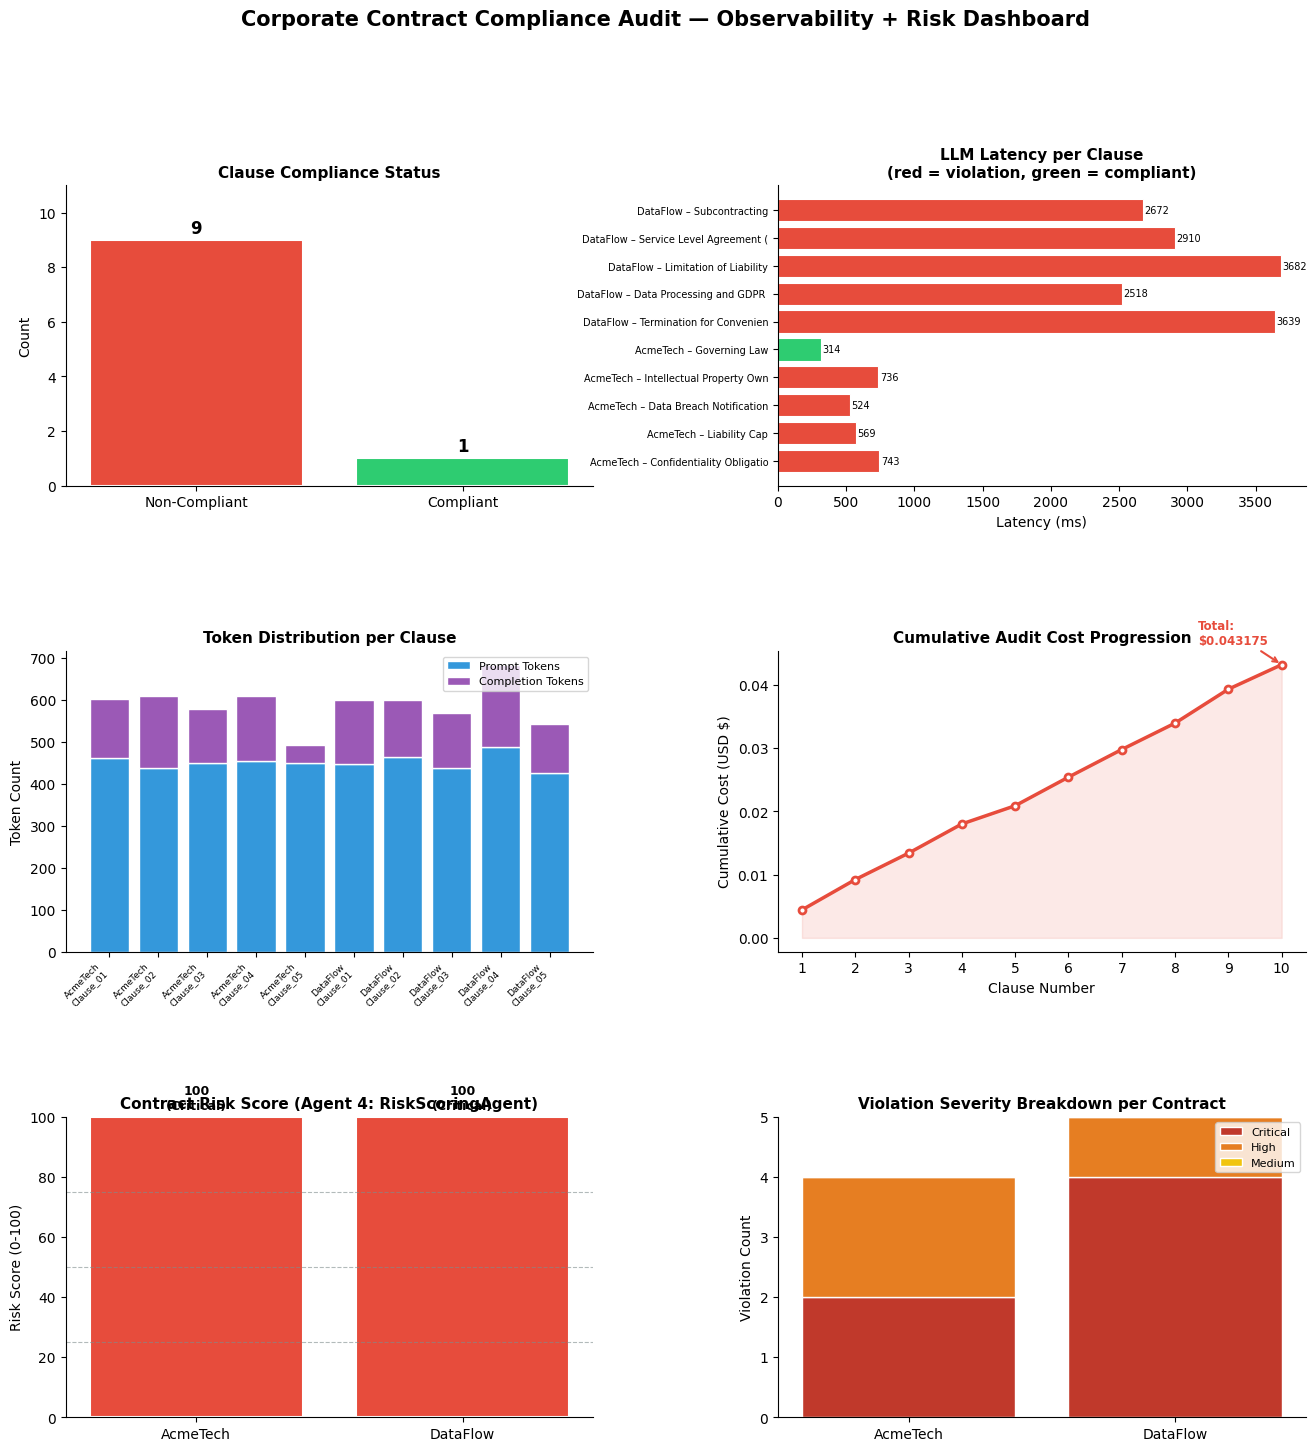

[Dashboard saved to /tmp/audit_dashboard.png]

══════════════════════════════════════════════════════════════════════
  FULL CLAUSE-LEVEL AUDIT DATAFRAME
══════════════════════════════════════════════════════════════════════
          Vendor Name Clause ID                        Clause Label Compliance Status Policy Severity  Latency (ms)  Prompt Tokens  Completion Tokens  Total Cost ($)                                                               Retrieved Policy                                                                                                           Violation Summary
        AcmeTech Ltd. Clause_01          Confidentiality Obligation     Non-Compliant            High    742.978000            461                141        0.004420      [POL-003] Confidentiality (High) | [POL-006] Intellectual Property (High) The confidentiality obligation period of one year is less than the minimum required period of three years as stated in P...
        AcmeTech Ltd. Clause_02      

In [13]:
# ==============================================================
# CELL 14 — REAL-TIME OBSERVABILITY SUMMARY & DASHBOARD
# ==============================================================
# This cell produces:
#   A) A printed financial + operational audit report (text)
#   B) A per-contract compliance summary table
#   C) A per-contract RISK SCORE summary table (Agent 4 output)
#   D) A 3×2 Matplotlib dashboard with:
#        1. Compliance status breakdown (bar chart)
#        2. Per-clause latency (horizontal bar)
#        3. Token distribution: prompt vs completion (stacked bar)
#        4. Cumulative cost per clause (line chart)
#        5. Risk Score per contract (bar, colour-coded by category)
#        6. Violation severity breakdown across contracts (stacked bar)
# ==============================================================

# ── Aggregate metrics ─────────────────────────────────────────
total_clauses:        int   = len(audit_df)
total_violations:     int   = audit_df["Is Violation"].sum()
total_compliant:      int   = (audit_df["Compliance Status"] == "Compliant").sum()
total_parse_errors:   int   = (audit_df["Compliance Status"] == "Parse Error").sum()
violation_rate_pct:   float = round((total_violations / total_clauses) * 100, 1)

total_prompt_tokens:      int   = int(audit_df["Prompt Tokens"].sum())
total_completion_tokens:  int   = int(audit_df["Completion Tokens"].sum())
total_tokens_consumed:    int   = int(audit_df["Total Tokens"].sum())
total_input_cost_usd:     float = float(audit_df["Input Cost ($)"].sum())
total_output_cost_usd:    float = float(audit_df["Output Cost ($)"].sum())
total_cost_usd:           float = float(audit_df["Total Cost ($)"].sum())

avg_latency_ms:           float = round(float(audit_df["Latency (ms)"].mean()), 1)
max_latency_ms:           float = round(float(audit_df["Latency (ms)"].max()),  1)
min_latency_ms:           float = round(float(audit_df["Latency (ms)"].min()),  1)
total_latency_ms:         float = round(float(audit_df["Latency (ms)"].sum()),  1)

total_rewrite_cost_usd:   float = float(risk_df["Rewrite Cost ($)"].sum())
total_review_cost_usd:    float = float(risk_df["Review Cost ($)"].sum())
total_rewritten_clauses:  int   = int(risk_df["Rewritten Clauses"].sum())
total_verified_clauses:   int   = int(risk_df["Verified by Reviewer"].sum())
total_flagged_for_human:  int   = int(risk_df["Flagged for Human"].sum())
total_rejudges:           int   = int(risk_df["Re-judges Triggered"].sum())
grand_total_cost_usd:     float = round(total_cost_usd + total_rewrite_cost_usd + total_review_cost_usd, 8)

# ── Section A: Printed Financial & Operational Report ─────────
print("\n" + "═" * 70)
print("  CORPORATE CONTRACT COMPLIANCE AUDIT — EXECUTIVE REPORT")
print("═" * 70)
print(f"  Audit Timestamp        : {time.strftime('%Y-%m-%d %H:%M:%S UTC', time.gmtime())}")
print(f"  LLM Model              : {LLM_MODEL}")
print(f"  Total Contracts Audited: {len(CONTRACTS_TO_AUDIT)}")
print(f"  Total Clauses Reviewed : {total_clauses}")
print()
print("  ── COMPLIANCE SUMMARY ────────────────────────────────")
print(f"  Compliant Clauses      : {total_compliant:>5}  ({round(total_compliant/total_clauses*100,1)}%)")
print(f"  Non-Compliant Clauses  : {total_violations:>5}  ({violation_rate_pct}%)  ← VIOLATIONS")
print(f"  Parse Errors           : {total_parse_errors:>5}")
print()
print("  ── OPERATIONAL METRICS ───────────────────────────────")
print(f"  Total Pipeline Runtime : {total_pipeline_seconds:>8.2f} s  ({total_pipeline_ms:.0f} ms)")
print(f"  Total LLM Latency      : {total_latency_ms:>8.1f} ms")
print(f"  Average Latency/Clause : {avg_latency_ms:>8.1f} ms")
print(f"  Fastest Clause         : {min_latency_ms:>8.1f} ms")
print(f"  Slowest Clause         : {max_latency_ms:>8.1f} ms")
print()
print("  ── TOKEN CONSUMPTION ─────────────────────────────────")
print(f"  Total Prompt Tokens    : {total_prompt_tokens:>8,}")
print(f"  Total Completion Tokens: {total_completion_tokens:>8,}")
print(f"  Total Tokens Consumed  : {total_tokens_consumed:>8,}")
print(f"  Avg Tokens / Clause    : {round(total_tokens_consumed / total_clauses):>8,}")
print()
print("  ── FINANCIAL COST BREAKDOWN ──────────────────────────")
print(f"  Input Token Cost       : ${total_input_cost_usd:>12.6f}  ({total_prompt_tokens:,} × $5.00/M)")
print(f"  Output Token Cost      : ${total_output_cost_usd:>12.6f}  ({total_completion_tokens:,} × $15.00/M)")
print(f"  Judging Subtotal       : ${total_cost_usd:>12.6f}")
print(f"  Rewriter Subtotal       : ${total_rewrite_cost_usd:>12.6f}  ({total_rewritten_clauses} clause(s) rewritten)")
print(f"  Reviewer Subtotal       : ${total_review_cost_usd:>12.6f}  ({total_verified_clauses + total_flagged_for_human} verification(s) run)")
print(f"  ─────────────────────────────────────────────────────")
print(f"  GRAND TOTAL COST (USD) : ${grand_total_cost_usd:>12.6f}")
print(f"  Cost per Clause Judged : ${total_cost_usd/total_clauses:>12.6f}")
print("═" * 70)
print()
print("  ── AGENTIC RETRY LOOPS (ORCHESTRATOR-DRIVEN) ─────────")
print(f"  Confidence-Triggered Re-judges (Agent 6→3): {total_rejudges:>4}")
print(f"  Rewrites Verified OK by Reviewer (Agent 7) : {total_verified_clauses:>4}")
print(f"  Rewrites Flagged for Human Review          : {total_flagged_for_human:>4}")
print("═" * 70)

# ── Section B: Per-contract violation summary ─────────────────
print("\n  ── PER-CONTRACT VIOLATION BREAKDOWN ──────────────────")
contract_summary = audit_df.groupby(["Vendor Name", "Contract Type"]).agg(
    Total_Clauses    = ("Clause ID",          "count"),
    Violations       = ("Is Violation",        "sum"),
    Total_Tokens     = ("Total Tokens",        "sum"),
    Total_Cost_USD   = ("Total Cost ($)",       "sum"),
    Avg_Latency_ms   = ("Latency (ms)",        "mean"),
).reset_index()
contract_summary["Violation Rate"] = (
    contract_summary["Violations"] / contract_summary["Total_Clauses"] * 100
).round(1).astype(str) + "%"
contract_summary["Total_Cost_USD"] = contract_summary["Total_Cost_USD"].map("${:.6f}".format)
contract_summary["Avg_Latency_ms"] = contract_summary["Avg_Latency_ms"].round(1).astype(str) + " ms"
print(contract_summary.to_string(index=False))

# ── Section C: Per-contract RISK SCORE summary (Agent 4) ───────
print("\n  ── PER-CONTRACT RISK SCORE (AGENT 4: RiskScoringAgent) ──")
risk_summary_cols = [
    "Vendor Name", "Risk Score (0-100)", "Risk Category",
    "Non-Compliant", "Critical Violations", "High Violations",
    "Medium Violations", "Top Risk Clauses",
]
print(risk_df[risk_summary_cols].to_string(index=False))

# ── Section C2: Agentic retry-loop summary (Agents 6, 7) ───────
print("\n  ── AGENTIC RETRY LOOP SUMMARY (AGENTS 6 & 7) ──────────")
retry_summary_cols = [
    "Vendor Name", "Re-judges Triggered", "Rewritten Clauses",
    "Verified by Reviewer", "Flagged for Human",
]
print(risk_df[retry_summary_cols].to_string(index=False))

# ── Section D: Violations table ───────────────────────────────
print("\n  ── NON-COMPLIANT CLAUSES (DETAILED) ──────────────────")
violations_df = audit_df[audit_df["Is Violation"]][[
    "Vendor Name", "Clause ID", "Clause Label", "Policy Severity", "Retrieved Policy", "Violation Summary"
]].reset_index(drop=True)
pd.set_option("display.max_colwidth", 80)
print(violations_df.to_string(index=False))

# ── Section E: Matplotlib Observability Dashboard (3×2 grid) ───
fig = plt.figure(figsize=(16, 16))
fig.suptitle(
    "Corporate Contract Compliance Audit — Observability + Risk Dashboard",
    fontsize=15, fontweight="bold", y=0.99
)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)

# Colour palette
COLOR_COMPLIANT     = "#2ecc71"   # green
COLOR_VIOLATION     = "#e74c3c"   # red
COLOR_ERROR         = "#e67e22"   # orange
COLOR_PROMPT        = "#3498db"   # blue
COLOR_COMPLETION    = "#9b59b6"   # purple
COLOR_COST          = "#e74c3c"   # red
COLOR_LATENCY       = "#1abc9c"   # teal

RISK_CATEGORY_COLORS: Dict[str, str] = {
    "Low":      "#2ecc71",
    "Medium":   "#f1c40f",
    "High":     "#e67e22",
    "Critical": "#e74c3c",
}
SEVERITY_COLORS: Dict[str, str] = {
    "Critical": "#c0392b",
    "High":     "#e67e22",
    "Medium":   "#f1c40f",
    "Low":      "#95a5a6",
}

# ── Chart 1: Compliance status breakdown ──────────────────────
ax1 = fig.add_subplot(gs[0, 0])
status_counts = audit_df["Compliance Status"].value_counts()
bar_colors = [
    COLOR_COMPLIANT if s == "Compliant"
    else COLOR_VIOLATION if s == "Non-Compliant"
    else COLOR_ERROR
    for s in status_counts.index
]
bars = ax1.bar(status_counts.index, status_counts.values, color=bar_colors, edgecolor="white", linewidth=1.5)
ax1.set_title("Clause Compliance Status", fontweight="bold", fontsize=11)
ax1.set_ylabel("Count")
ax1.set_ylim(0, status_counts.max() + 2)
for bar, val in zip(bars, status_counts.values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        str(val),
        ha="center", va="bottom", fontweight="bold", fontsize=12
    )
ax1.spines[["top", "right"]].set_visible(False)

# ── Chart 2: Per-clause latency (horizontal bar) ──────────────
ax2 = fig.add_subplot(gs[0, 1])
clause_labels = [
    f"{row['Vendor Name'].split()[0]} – {row['Clause Label'][:25]}"
    for _, row in audit_df.iterrows()
]
latency_values = audit_df["Latency (ms)"].tolist()
y_positions    = range(len(clause_labels))
bar_h_colors   = [
    COLOR_VIOLATION if is_v else COLOR_COMPLIANT
    for is_v in audit_df["Is Violation"].tolist()
]
h_bars = ax2.barh(list(y_positions), latency_values, color=bar_h_colors, edgecolor="white", linewidth=0.8)
ax2.set_yticks(list(y_positions))
ax2.set_yticklabels(clause_labels, fontsize=7)
ax2.set_xlabel("Latency (ms)")
ax2.set_title("LLM Latency per Clause\n(red = violation, green = compliant)",
              fontweight="bold", fontsize=11)
ax2.spines[["top", "right"]].set_visible(False)
for bar, val in zip(h_bars, latency_values):
    ax2.text(
        bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
        f"{val:.0f}", va="center", fontsize=7
    )

# ── Chart 3: Prompt vs Completion token distribution ──────────
ax3 = fig.add_subplot(gs[1, 0])
clause_ids     = audit_df["Clause ID"].tolist()
prompt_vals    = audit_df["Prompt Tokens"].tolist()
completion_vals = audit_df["Completion Tokens"].tolist()
x_positions    = range(len(clause_ids))
ax3.bar(list(x_positions), prompt_vals,     label="Prompt Tokens",     color=COLOR_PROMPT,     edgecolor="white")
ax3.bar(list(x_positions), completion_vals, label="Completion Tokens", color=COLOR_COMPLETION, bottom=prompt_vals, edgecolor="white")
ax3.set_xticks(list(x_positions))
ax3.set_xticklabels(
    [f"{cid}\n{v}" for cid, v in zip(audit_df["Vendor Name"].str.split().str[0], clause_ids)],
    fontsize=6.5, rotation=45, ha="right"
)
ax3.set_ylabel("Token Count")
ax3.set_title("Token Distribution per Clause", fontweight="bold", fontsize=11)
ax3.legend(fontsize=8, loc="upper right")
ax3.spines[["top", "right"]].set_visible(False)

# ── Chart 4: Cumulative cost progression (line chart) ─────────
ax4 = fig.add_subplot(gs[1, 1])
cumulative_cost = audit_df["Total Cost ($)"].cumsum().tolist()
clause_sequence = list(range(1, len(cumulative_cost) + 1))
ax4.plot(
    clause_sequence, cumulative_cost,
    color=COLOR_COST, linewidth=2.5, marker="o", markersize=5,
    markerfacecolor="white", markeredgecolor=COLOR_COST, markeredgewidth=2
)
ax4.fill_between(clause_sequence, cumulative_cost, alpha=0.12, color=COLOR_COST)
ax4.set_xlabel("Clause Number")
ax4.set_ylabel("Cumulative Cost (USD $)")
ax4.set_title("Cumulative Audit Cost Progression", fontweight="bold", fontsize=11)
ax4.set_xticks(clause_sequence)
# Annotate final cost
ax4.annotate(
    f"Total:\n${total_cost_usd:.6f}",
    xy=(clause_sequence[-1], cumulative_cost[-1]),
    xytext=(-60, 15), textcoords="offset points",
    fontsize=8.5, fontweight="bold", color=COLOR_COST,
    arrowprops=dict(arrowstyle="->", color=COLOR_COST, lw=1.5)
)
ax4.spines[["top", "right"]].set_visible(False)

# ── Chart 5: Risk Score per contract (Agent 4 output) ──────────
ax5 = fig.add_subplot(gs[2, 0])
risk_vendor_labels = risk_df["Vendor Name"].str.split().str[0].tolist()
risk_scores         = risk_df["Risk Score (0-100)"].tolist()
risk_categories      = risk_df["Risk Category"].tolist()
risk_bar_colors      = [RISK_CATEGORY_COLORS.get(c, "#95a5a6") for c in risk_categories]
risk_bars = ax5.bar(risk_vendor_labels, risk_scores, color=risk_bar_colors, edgecolor="white", linewidth=1.5)
ax5.set_ylim(0, 100)
ax5.axhline(25, color="#7f8c8d", linestyle="--", linewidth=0.8, alpha=0.6)
ax5.axhline(50, color="#7f8c8d", linestyle="--", linewidth=0.8, alpha=0.6)
ax5.axhline(75, color="#7f8c8d", linestyle="--", linewidth=0.8, alpha=0.6)
ax5.set_ylabel("Risk Score (0-100)")
ax5.set_title("Contract Risk Score (Agent 4: RiskScoringAgent)", fontweight="bold", fontsize=11)
for bar, score, category in zip(risk_bars, risk_scores, risk_categories):
    ax5.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
        f"{score}\n({category})", ha="center", va="bottom", fontweight="bold", fontsize=9
    )
ax5.spines[["top", "right"]].set_visible(False)

# ── Chart 6: Violation severity breakdown per contract ─────────
ax6 = fig.add_subplot(gs[2, 1])
severity_order = ["Critical", "High", "Medium", "Low"]
bottom = [0] * len(risk_df)
for severity in severity_order:
    col_name = f"{severity} Violations"
    if col_name not in risk_df.columns:
        continue
    values = risk_df[col_name].tolist()
    ax6.bar(
        risk_vendor_labels, values, bottom=bottom,
        label=severity, color=SEVERITY_COLORS[severity], edgecolor="white",
    )
    bottom = [b + v for b, v in zip(bottom, values)]
ax6.set_ylabel("Violation Count")
ax6.set_title("Violation Severity Breakdown per Contract", fontweight="bold", fontsize=11)
ax6.legend(fontsize=8, loc="upper right")
ax6.spines[["top", "right"]].set_visible(False)

plt.savefig("/tmp/audit_dashboard.png", dpi=150, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()
print("[Dashboard saved to /tmp/audit_dashboard.png]")

# ── Final detailed DataFrame output ───────────────────────────
print("\n" + "═" * 70)
print("  FULL CLAUSE-LEVEL AUDIT DATAFRAME")
print("═" * 70)
pd.set_option("display.max_colwidth", 70)
detailed_display_cols = [
    "Vendor Name", "Clause ID", "Clause Label", "Compliance Status",
    "Policy Severity", "Latency (ms)", "Prompt Tokens", "Completion Tokens",
    "Total Cost ($)", "Retrieved Policy", "Violation Summary",
]
print(audit_df[detailed_display_cols].to_string(index=False))

print("\n" + "═" * 70)
print("  AUDIT PIPELINE COMPLETE")
print(f"  {total_compliant} compliant, {total_violations} violations across"
      f" {total_clauses} clauses in {total_pipeline_seconds}s — Judging cost: ${total_cost_usd:.6f}")
print("═" * 70)
print("\n[✓] Cell 14 complete — Full observability + risk dashboard rendered.")


In [14]:
# ==============================================================
# CELL 15 — AGENT 5 + 7 OUTPUT: REVISED, VERIFIED CONTRACTS
# ==============================================================
# This cell prints the final deliverable that a legal/procurement
# reviewer actually wants: a complete, ready-to-use revised version
# of each contract, with every Non-Compliant clause rewritten by
# ContractRewriterAgent (Agent 5) and independently verified by
# ReviewerAgent (Agent 7) before being accepted.
#
# Each revised clause is tagged:
#   [REVISED FOR COMPLIANCE — VERIFIED OK]   passed review
#   [REVISED — NEEDS HUMAN REVIEW]           failed review after retries
# so a reviewer can see at a glance exactly what changed AND whether
# the system itself trusts the fix or wants a human to double-check it.
# ==============================================================

for report in all_reports:
    contract = report.contract
    ra       = report.risk_assessment

    verified_count = sum(1 for o in report.review_outcomes if o.final_passed)
    flagged_count  = sum(1 for o in report.review_outcomes if not o.final_passed)

    print("\n" + "█" * 72)
    print(f"  REVISED CONTRACT — {contract.vendor_name} ({contract.contract_type})")
    print(f"  Risk Score: {ra.risk_score}/100  ({ra.risk_category} Risk)  |  "
          f"{report.rewriter_metrics['clauses_rewritten']} clause(s) rewritten  |  "
          f"{verified_count} verified OK, {flagged_count} flagged for human review  |  "
          f"${report.rewriter_metrics['total_cost_usd']:.6f} rewrite + "
          f"${report.reviewer_metrics['total_cost_usd']:.6f} review cost")
    print("█" * 72)
    print(report.revised_contract_text)

    if flagged_count:
        print(f"\n  ⚠ HUMAN REVIEW NEEDED on {flagged_count} clause(s) in this contract:")
        for outcome in report.review_outcomes:
            if not outcome.final_passed:
                last_reason = outcome.review_history[-1].review_reason if outcome.review_history else "Unknown"
                print(f"    • {outcome.clause_label} (after {outcome.attempts} attempt(s)): {last_reason[:140]}")
    print()

print("\n" + "═" * 70)
print("  ALL CONTRACTS REVISED & VERIFIED")
print(f"  {len(all_reports)} contract(s) processed | "
      f"{total_rewritten_clauses} clause(s) rewritten | "
      f"{total_verified_clauses} verified OK by ReviewerAgent | "
      f"{total_flagged_for_human} flagged for human review")
print(f"  Total rewrite cost: ${total_rewrite_cost_usd:.6f}  |  Total review cost: ${total_review_cost_usd:.6f}")
print("═" * 70)
print("\n[✓] Cell 15 complete — Revised, verified, compliance-ready contracts rendered.")



████████████████████████████████████████████████████████████████████████
  REVISED CONTRACT — AcmeTech Ltd. (Mutual NDA)
  Risk Score: 100/100  (Critical Risk)  |  4 clause(s) rewritten  |  4 verified OK, 0 flagged for human review  |  $0.011405 rewrite + $0.013380 review cost
████████████████████████████████████████████████████████████████████████
REVISED MUTUAL NDA
Vendor: AcmeTech Ltd.
Document ID: 07a47476-50bb-4f4b-9adb-e6ebffb92df3

1. Confidentiality Obligation [REVISED FOR COMPLIANCE — VERIFIED OK]
Each party agrees to maintain the confidentiality of the other party's Confidential Information and shall not disclose it to any third party without prior written consent. This obligation shall remain in effect for a period of not less than THREE (3) years from the date of disclosure or from the date of contract termination, whichever is later.

2. Liability Cap [REVISED FOR COMPLIANCE — VERIFIED OK]
In no event shall either party's total liability arising out of or related to this 

---
## What This Capstone Demonstrated

| Component | Implementation | What It Does |
|---|---|---|
| **SimulatedS3Client** | `boto3`-compatible interface class | Ingests raw contract documents from cloud storage |
| **ContractParserAgent** (Agent 1) | Groq LLM + regex fallback | Splits raw, unstructured contract text into labelled clauses |
| **PolicyRetrievalAgent** (Agent 2) | ChromaDB EphemeralClient + severity ranking | Retrieves top-k relevant policies per clause, re-ranked by severity then distance |
| **ComplianceJudgeAgent** (Agent 3) | Groq LLM (`llama-3.3-70b-versatile`) | Judges each clause Compliant/Non-Compliant with reason, suggested fix, and confidence score |
| **RiskScoringAgent** (Agent 4) | Pure Python, severity-weighted scoring | Aggregates verdicts into one 0-100 Risk Score + Low/Medium/High/Critical label |
| **ContractRewriterAgent** (Agent 5) | Groq LLM, targeted rewrites | Produces a complete, ready-to-use compliant version of the contract |
| **OrchestratorAgent** (Agent 6) | Pure Python coordinator | Drives execution order, runs confidence-gated retry loops, assembles the final `ContractAuditReport` |
| **ReviewerAgent** (Agent 7) | Groq LLM, adversarial QA pass | Independently verifies every rewritten clause before it's accepted; rejects rewrites that don't concretely satisfy policy |
| **CostMonitor** | `time.perf_counter()` + `tiktoken` | Measures ms-precision latency and exact BPE token counts; converts to USD |
| **ClauseAuditResult / ContractRiskAssessment / RewrittenClause / ReviewVerdict** | Python `dataclass`es | Immutable records tracking compliance, risk, rewrite, and verification fields |
| **Pandas DataFrames** | Clause-level + contract-level risk log | Flat, queryable tables for downstream analytics or export to CSV/BI tools |
| **Matplotlib Dashboard** | 3×2 chart grid | Compliance breakdown, latency, tokens, cumulative cost, risk score, severity breakdown |

### Architecture Takeaways

**Multi-agent separation of concerns** — Each agent owns exactly one responsibility (parsing, retrieval, judging, scoring, rewriting, reviewing, orchestration), making the system easier to test, swap, and extend independently.

**Genuine agentic control flow, not just a fixed pipeline** — `OrchestratorAgent` makes runtime decisions based on what other agents report about their own uncertainty. A low `confidence_score` from `ComplianceJudgeAgent` triggers an automatic re-judge with a wider policy window; a failed verdict from `ReviewerAgent` triggers a re-rewrite with the specific objection as feedback. This branching, confidence-driven behavior is what separates an agentic system from a linear five-function script — every agent's docstring documents its autonomy, reactivity, proactiveness, and social ability explicitly.

**Critic / Self-Refine pattern** — `ReviewerAgent` never trusts `ContractRewriterAgent`'s output at face value. It independently re-derives whether the rewrite satisfies the concrete, checkable terms of the policy (day counts, dollar caps, notice periods), and the Orchestrator routes failed reviews back for another attempt — closing the loop between "generate a fix" and "confirm the fix actually works."

**RAG-powered compliance** — ChromaDB's semantic retrieval, severity-ranked by `PolicyRetrievalAgent`, ensures the judge always sees the most relevant *and* most critical policy first, reducing hallucination and increasing verdict accuracy.

**Actionable risk quantification** — `RiskScoringAgent` turns a list of qualitative verdicts into one executive-friendly number (0-100) and category, so leadership can triage which contracts need attention first without reading every clause.

**Deterministic observability** — Every LLM call, including retry and review calls, is wrapped in a `time.perf_counter()` context manager and tiktoken counter before the response is ever parsed. Metrics are captured even if JSON parsing fails.

**Graceful degradation, with an explicit escape hatch to humans** — Every agent's JSON-parsing methods have layered fallbacks (direct parse → regex extraction → sentinel error record / regex clause splitter). When the system genuinely can't resolve something — a rewrite that fails review twice — it doesn't pretend to succeed; it labels the clause `NEEDS HUMAN REVIEW` in the final output instead of silently shipping an unverified fix.

**Production migration path** — Replace `SimulatedS3Client.get_contract()` with real `boto3` calls, and replace `ChromaDB.EphemeralClient()` with `chromadb.HttpClient()` pointing at a hosted Chroma cluster, to move this notebook to production with zero other changes. `OrchestratorAgent` already encapsulates the full pipeline including its retry logic, so swapping the ingestion layer is a one-line change.
